> **Validation correction (2026-07-10).** This notebook's `min(OPT_Ω+ε, H)` line is not a certified prompt ceiling. `OPT_Ω` is an adaptively selected achieved checklist value and `ε` is an unvalidated process-horizon extrapolation; all 46 source rows have `adv_saturated=null`. The only all-prompt upper bound shown by these data is the fixed-target DPI cap `H(M)` on the frozen probe distribution. `GEPA*`, `g1`, and `OPT_Ω` are best-observed values, not proven asymptotes. See `notes/2026-07-10__momega-certificate-audit.md`.


> **Update (2026-07-11).** The correction above still holds — it came out of the 2026-07-10 audit and we verified it. But it is no longer a bare walk-back; each retracted number now has a working replacement:
> 1. **Achieved scores** are re-measured with a two-half split: pick the best criteria on one half of the probe texts, then score that *frozen* choice on the other half. This removes the "lucky winner" inflation (~0.15 bits) that the audit found.
> 2. **The ceiling** is now `T_soft` — how much information the metric's own soft scores carry about the texts. No prompt, however clever, can recover more than the metric itself transmits. This is the only *certified* upper bound.
> 3. **"How much better could this metric get?"** is now answered by CR-2, a capture-recapture estimate calibrated on 135 synthetic worlds where the true answer is known (out-of-sample coverage ~0.82–0.86). It replaces the retracted ε. See `notes/2026-07-10__cr2-horizon-rehabilitation.md`.

> **Update 2 (2026-07-11).** Two further external reviews were accepted: the capture–recapture
> *estimate* (§8a) is now a descriptive saturation diagnostic only; the **certified** version is
> **CR-3** in §8b (`cr_audit.py`, discovery/audit split, exact Clopper–Pearson mass bounds). And
> `H(M_ω)` is demoted from “the ideal ceiling” to a self-fidelity diagnostic: the paper's ceiling
> is `T* = I(M*;X)`, reached via an identified-set bound over independent target views. See the
> ladder at the end of §8b and theory note §12.6b.

# Prompt search, visually: GEPA vs achieved checklist values and the DPI cap

**Theory:** `notes/2026-06-18__prompt-optimality-theory.md` (§3 ladder, §4.4a GEPA-is-a-generator, §6.5
Discovery-to-Selection, §12.6 unified certificate). **Driver:** `methods/metric_implementer/experiments/run_gepa_for_plot.py`.

**The comparison this notebook shows on one metric.** Prompt optimization (GEPA) is a *generator*: it takes a metric's
plain-language definition and tries to sharpen it, by failure-informed revision, into a rubric that better
reproduces the metric's verdicts and reaches an observed plateau. The decomposed criterion pool Ω supplies
additional achieved values; only `T=H(M)` supplies an all-prompt upper bound in these data. The picture:

```
bits ↑
  T = H(M) ────────────────────────────  information cap: verdict is deterministic given X ⇒ R ≤ T by DPI (§2.2)
              ▄▄▀▀▀▀▀  Ω staircase (best k-subset of decomposed units, k = 1,2,3,…) → OPT_Ω
  g₁       ────────────────────────────  best single decomposed criterion
  GEPA*    ══╤══════════════════════════  single-prompt plateau (best of description / its GEPA refinements / name)
             │__..——''  GEPA trajectory
  desc     ──┘                            round 0 = the metric's own description
        ───────────────────────────────→  GEPA iteration t
```

**Which y-axis metric?** Everything is Shannon **bits of recovery** `R(p) = I(M_i ; binarized verdict of p)`
against the metric's orbit-averaged verdict `M_i`, on the same frozen 300 probes with the same Llama-8B executor
the checklist run used. One axis makes the GEPA trajectory, the per-k combiner staircase, and the DPI cap
directly comparable. `T = I(M_i;X)` equals `H(M_i)` here (the verdict is a deterministic readout of the text), so
`T` is an empirical fixed-target cap and `R ≤ T` is the DPI relation (§2.2); the achieved floor drawn is `g₁`, the best single
criterion.

**Metric chosen:** creative-writing R3 #24 — *"Worldbuilding coherence, depth, and integration"* — picked from a
12-metric sweep because GEPA visibly **expands its description into checkable conditions** (the two accepted rounds
in §1) *and* it has a rich decomposed Ω (9-criterion head). Its historical form and ε diagnostics are retained
for sensitivity analysis, but neither produces a certified ceiling or CODIFIABLE verdict.

In [22]:
import json, textwrap
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA = Path("data/prompt_optimality_20260703")
GI = 24   # "Worldbuilding coherence, depth, and integration" — GEPA visibly expands the description here

cert_rows = json.load(open(DATA / "cert_8b_v2.json"))
cert = next(r for r in cert_rows if f"metric{GI}_" in r["file"])
lin  = json.load(open(DATA / f"gepa_lineage_cw_R3_g{GI}_desc.json"))   # DESCRIPTION-seeded run

H_M   = cert["H_M"]                      # = T = I(M;X): verdict deterministic given X (hard DPI cap)
gains = cert["gains"]                    # greedy per-criterion marginal gains (bits)
OPT   = cert["opt_omega_bits"]           # = sum(gains): achieved checklist recovery from this pool
EPS   = cert["eps_bits_adv"]             # historical process-horizon sensitivity; not a confidence bound
g1    = gains[0]                         # best single decomposed criterion

# H(M) is the only all-prompt upper bound here. OPT+EPS is retained as a historical heuristic only.
HEURISTIC_PROCESS_LINE = min(OPT + EPS, H_M)
CEIL = H_M

traj   = lin["lineage"]
R_t    = [t["R_bits"] for t in traj]
name_R = lin["name_R_bits"]              # metric NAME as a single prompt
desc_R = lin["desc_R_bits"]              # metric DESCRIPTION as a single prompt (= the seed, round 0)
best_gepa = max(R_t)
# GEPA* = the single-prompt plateau: the best recovery from ANY single prompt (seed, its GEPA
# refinements, or the bare name). One number, used identically in every figure below.
GEPA_STAR = max(best_gepa, name_R, desc_R)

print(f"metric #{GI}: {lin['metric']}")
print(f"executor: {lin['model']}   probes: {lin['n_probes']}   base rate P(M=1)={lin['M_i_mean']:.3f}")
print(f"seed = the metric DESCRIPTION (round 0): \"{traj[0]['prompt'][:88]}…\"")
print(f"measurement: T=H_M={H_M:.3f}b  achieved OPT_Ω={OPT:.3f}b  heuristic ε={EPS:.3f}b  g1={g1:.3f}b")
print(f"valid fixed-target DPI cap = {CEIL:.3f}b; historical min(OPT_Ω+ε,T) = {HEURISTIC_PROCESS_LINE:.3f}b")
print(f"GEPA (description seed): R {R_t[0]:.3f} → {best_gepa:.3f}b over {lin['rounds']} rounds "
      f"({sum(1 for t in traj[1:] if t['accepted'])} accepted)")
print(f"single-prompt rungs: description {desc_R:.3f}b · name {name_R:.3f}b  ⇒  GEPA* = {GEPA_STAR:.3f}b")
print(f"\nthe observed ordering: GEPA* {GEPA_STAR:.2f} < g1 {g1:.2f} < OPT_Ω {OPT:.2f} ≤ T cap {CEIL:.2f}")

metric #24: Worldbuilding coherence, depth, and integration
executor: meta-llama/Llama-3.1-8B-Instruct   probes: 300   base rate P(M=1)=0.790
seed = the metric DESCRIPTION (round 0): "Construct consistent systems and lived‑in cultures; reveal economically through characte…"
measurement: T=H_M=0.741b  achieved OPT_Ω=0.585b  heuristic ε=0.597b  g1=0.327b
valid fixed-target DPI cap = 0.741b; historical min(OPT_Ω+ε,T) = 0.741b
GEPA (description seed): R 0.201 → 0.245b over 6 rounds (1 accepted)
single-prompt rungs: description 0.201b · name 0.203b  ⇒  GEPA* = 0.245b

the observed ordering: GEPA* 0.25 < g1 0.33 < OPT_Ω 0.58 ≤ T cap 0.74


### What "GEPA*" (the single-prompt plateau) means in each figure

One definition everywhere: **GEPA\* = the best recovery achieved by ANY single prompt for that metric** — the
empirical asymptote of single-prompt optimization. Concretely `GEPA* = max(best GEPA round, description rung,
name rung)`. It appears as:

| figure | how GEPA* shows up |
|---|---|
| §2 Plot 1 (trajectory) | purple horizontal line — the level the blue GEPA curve flattens to |
| §4 Plot 2 (Ω staircase) | same purple line — the level the checklist staircase climbs past |
| §6 scatter (bank-wide) | the **x-axis** (`R_single = max(name, desc)` per metric) |
| §7 boxplot (aggregate) | the three purple reference boxes (name rung / description rung / best-single-of-anything) |

For the showcase metric #24, GEPA\* = 0.245 b — the description seed of 0.201 b lifted by the one accepted
revision. This is the honest asymptote: it is *whichever* single prompt won — seed, GEPA refinement, or bare
name — because the plateau is a property of the **single-prompt class**, not of the optimizer.

## 1. The prompts over time — what GEPA actually wrote

**Round 0 is the metric's own description** — the human-written definition of #24: *"Construct consistent
systems and lived-in cultures; reveal economically through character experience; pace terminology/logistics so
richness remains clear and functional to story/theme."* That is the natural starting point a practitioner would
write down, and it already recovers 0.201 bits. GEPA's job is to sharpen it into a YES/NO rubric that reproduces
the metric's verdicts better.

Each round a strong reviser (GLM) sees the concept **name**, the incumbent rubric, a calibration line (target
YES-rate vs current), and 4+4 misclassified excerpts, then proposes candidate rewrites; the best-by-R is accepted
only if it beats the incumbent. (The reviser knowing the metric's *name* is legitimate — an optimizer should know
its objective; that is standard GEPA.)

The cards below render each round as an **edited diff** against the previous accepted prompt: <ins>green =
text GEPA added</ins>, <del>red strikethrough = text it removed</del>. Rounds where every candidate scored below
the incumbent collapse to a slim bar (the prompt did not change). Watch the terse description turn into explicit
conditions: the accepted revision rewrites "consistent systems / lived-in cultures" into checkable YES/NO rules
("say YES only when coherent structures inform the story's conflict or themes… say NO to generic backdrop, stock
genre furniture, convenient logic gaps") and adds a disqualifier learned from the errors ("say NO when the prose
is primarily jokes, surreal absurdism, or chaotic voice with no functioning world architecture"). Then it
plateaus — the remaining rounds find nothing better.

In [23]:
import difflib
from IPython.display import HTML, display

# palette works on light and dark backgrounds (translucent backgrounds, inherited text color)
_CSS = """
<style>
.gepa-card {border:1px solid rgba(128,128,128,.35); border-radius:8px; margin:10px 0;
            font-family:-apple-system,'Segoe UI',sans-serif; overflow:hidden;}
.gepa-hdr  {padding:7px 12px; font-size:13px; font-weight:600; display:flex; gap:14px;
            align-items:baseline; border-bottom:1px solid rgba(128,128,128,.25);}
.gepa-hdr .rnd {font-size:14px;}
.gepa-acc  {background:rgba(46,160,67,.14);}
.gepa-rej  {background:rgba(128,128,128,.12);}
.gepa-seed {background:rgba(137,87,229,.14);}
.gepa-badge{font-size:11px; font-weight:700; padding:1px 8px; border-radius:10px;}
.b-acc {background:rgba(46,160,67,.35);}
.b-rej {background:rgba(128,128,128,.35);}
.b-seed{background:rgba(137,87,229,.32);}
.gepa-R    {font-variant-numeric:tabular-nums; font-weight:700;}
.gepa-body {padding:10px 14px; font-size:13.5px; line-height:1.65;}
.gepa-body ins {background:rgba(46,160,67,.28); text-decoration:none; border-radius:2px; padding:0 1px;}
.gepa-body del {background:rgba(248,81,73,.25); text-decoration:line-through; opacity:.65;
                border-radius:2px; padding:0 1px;}
.unit-row  {display:flex; align-items:center; gap:10px; margin:4px 0; font-size:13px;
            font-family:-apple-system,'Segoe UI',sans-serif;}
.unit-bar  {height:13px; background:linear-gradient(90deg,#2ea043,#56d364); border-radius:3px;
            min-width:2px;}
.unit-bar.freegen {background:linear-gradient(90deg,#1f6feb,#58a6ff);}
.unit-gain {width:70px; text-align:right; font-variant-numeric:tabular-nums; font-weight:600;}
.unit-tag  {font-size:10px; font-weight:700; padding:1px 6px; border-radius:8px;
            background:rgba(128,128,128,.25); width:52px; text-align:center;}
</style>
"""

def _word_diff_html(old, new):
    a, b = old.split(), new.split()
    out = []
    for op, i1, i2, j1, j2 in difflib.SequenceMatcher(None, a, b, autojunk=False).get_opcodes():
        if op == "equal":
            out.append(" ".join(b[j1:j2]))
        if op in ("delete", "replace"):
            out.append("<del>" + " ".join(a[i1:i2]) + "</del>")
        if op in ("insert", "replace"):
            out.append("<ins>" + " ".join(b[j1:j2]) + "</ins>")
    return " ".join(x for x in out if x)

def render_gepa_diffs(lineage, n_probes, metric_name=None, seed_label="seed", note=None):
    """Each round rendered as a card: text shown as a word-diff vs the PREVIOUS accepted prompt
    (green = added, red strikethrough = removed). Round 0 is the seed (shown verbatim). Rounds
    where every candidate scored below the incumbent collapse to a slim bar. ``metric_name`` draws
    a banner making clear the metric is NOT any single prompt below."""
    html = [_CSS]
    if metric_name:
        html.append(
            "<div style='border:1px solid rgba(137,87,229,.5); border-radius:8px; margin:6px 0 12px; "
            "padding:9px 13px; background:rgba(137,87,229,.10); font-family:-apple-system,sans-serif'>"
            "<span style='font-size:11px; font-weight:700; letter-spacing:.05em; opacity:.7'>"
            "METRIC BEING OPTIMIZED TOWARD</span><br>"
            "<span style='font-size:15px; font-weight:700'>" + metric_name + "</span>"
            "<span style='font-size:12.5px; opacity:.7'> &nbsp;— the prompts below are GEPA's "
            "attempts to write a YES/NO rubric that reproduces this metric's verdicts; none of them "
            "IS the metric.</span></div>")
    if note:
        html.append("<p style='font-size:12.5px;opacity:.75'>" + note + "</p>")
    prev = None
    for t in lineage:
        acc = t["accepted"]
        is_seed = (t["round"] == 0)
        if is_seed:
            cls, rlabel = "gepa-seed", "round 0 · " + seed_label
            badge = "<span class='gepa-badge b-seed'>starting point</span>"
        elif acc:
            cls, rlabel = "gepa-acc", "round " + str(t["round"])
            badge = "<span class='gepa-badge b-acc'>ACCEPTED (improved)</span>"
        else:
            cls, rlabel = "gepa-rej", "round " + str(t["round"])
            badge = "<span class='gepa-badge b-rej'>all candidates rejected</span>"
        hdr = ("<div class='gepa-hdr " + cls + "'>"
               "<span class='rnd'>" + rlabel + "</span>" + badge +
               "<span class='gepa-R'>R = " + format(t["R_bits"], ".3f") + " bits</span>"
               "<span style='opacity:.7'>YES on " + str(t["n_yes"]) + "/" + str(n_probes) + "</span></div>")
        show_body = is_seed or acc
        if show_body:
            body = _word_diff_html(prev, t["prompt"]) if (prev is not None and not is_seed) else t["prompt"]
            html.append("<div class='gepa-card'>" + hdr + "<div class='gepa-body'>" + body + "</div></div>")
            prev = t["prompt"]
        else:
            html.append("<div class='gepa-card'>" + hdr + "</div>")
    return HTML("".join(html))

def render_units(units, title):
    """units = [(gain_bits, source_tag, criterion_text)] — gain bars on a shared scale."""
    gmax = max(g for g, _, _ in units)
    rows = ["<h4 style='font-family:-apple-system,sans-serif;margin:14px 0 6px'>" + title + "</h4>"]
    for g, src, txt in units:
        w = max(2, int(260 * g / gmax))
        rows.append("<div class='unit-row'><span class='unit-gain'>+" + format(g, ".3f") + "b</span>"
                    "<span class='unit-tag'>" + src + "</span>"
                    "<span class='unit-bar " + src + "' style='width:" + str(w) + "px'></span>"
                    "<span>" + txt + "</span></div>")
    return HTML(_CSS + "".join(rows))

In [24]:
display(render_gepa_diffs(
    traj, lin["n_probes"], metric_name=lin["metric"], seed_label="the metric's DESCRIPTION",
    note=("Round 0 is the metric's own description (the natural GEPA starting point). Each later "
          "accepted round is diffed against the previous one: "
          "<ins style='background:rgba(46,160,67,.28);text-decoration:none'>green = text GEPA added</ins>, "
          "<del style='background:rgba(248,81,73,.25)'>red = text it removed</del>. "
          "Rounds where every candidate scored below the incumbent show as slim bars — "
          "the prompt did not change.")))
display(HTML(
    f"<div class='gepa-card'><div class='gepa-hdr' style='background:rgba(137,87,229,.18)'>"
    f"<span class='rnd'>reference: the metric NAME used directly as a prompt</span>"
    f"<span class='gepa-R'>R = {name_R:.3f} bits</span></div>"
    f"<div class='gepa-body'>&ldquo;{lin['metric']}&rdquo;</div></div>"))
print(f"single-prompt rungs — description (seed) {desc_R:.3f}b · name {name_R:.3f}b · "
      f"best GEPA round {best_gepa:.3f}b   ⇒   GEPA* = {GEPA_STAR:.3f}b")

single-prompt rungs — description (seed) 0.201b · name 0.203b · best GEPA round 0.245b   ⇒   GEPA* = 0.245b


## 2. Plot 1 — recovery per GEPA iteration, bracketed by the bounds

- **blue solid** — `R(p_t)`, the accepted prompt each round, starting from the description (gray dots: rejected
  candidate revisions);
- **purple solid** — `GEPA*`: the single-prompt plateau (best of description / GEPA rounds / name);
- **green thin** — `g₁`: best single decomposed Ω criterion — the floor an optimizer should clear;
- **red dotted** — `T = H(M)`: the empirical fixed-target DPI cap (`R ≤ T`);
- `OPT_Ω+ε` is not drawn because ε is not a validated confidence bound.

For #24, the historical `OPT_Ω+ε` value overshoots `T`. This illustrates why capping an invalid estimator
does not repair it: the plotted upper bound is `T` itself, while ε is reported only as sensitivity.

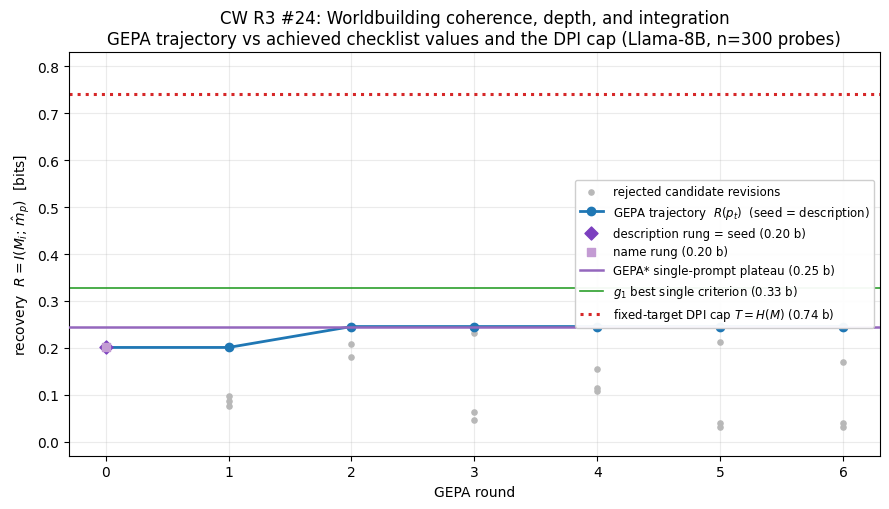

In [25]:
fig, ax = plt.subplots(figsize=(9, 5.2))
rounds = [t["round"] for t in traj]

for t in traj:
    for c in t.get("candidates", []):
        ax.scatter(t["round"], c["R_bits"], s=14, color="0.72", zorder=2)
ax.scatter([], [], s=14, color="0.72", label="rejected candidate revisions")

ax.plot(rounds, R_t, "o-", color="#1f77b4", lw=2, zorder=3,
        label="GEPA trajectory  $R(p_t)$  (seed = description)")
ax.scatter([0], [desc_R], marker="D", s=44, color="#7b3fbf", zorder=5,
           label=f"description rung = seed ({desc_R:.2f} b)")
ax.scatter([0], [name_R], marker="s", s=40, color="#c39bd3", zorder=5,
           label=f"name rung ({name_R:.2f} b)")

ax.axhline(GEPA_STAR, color="#9467bd", lw=1.8, zorder=3,
           label=f"GEPA* single-prompt plateau ({GEPA_STAR:.2f} b)")
ax.axhline(g1, color="#2ca02c", lw=1.2, label=f"$g_1$ best single criterion ({g1:.2f} b)")
ax.axhline(CEIL, color="#d62728", ls=":", lw=2.2,
           label=f"fixed-target DPI cap $T=H(M)$ ({CEIL:.2f} b)")

ax.set_xlabel("GEPA round")
ax.set_ylabel("recovery  $R = I(M_i;\\,\\hat m_p)$  [bits]")
ax.set_title(f"CW R3 #{GI}: {lin['metric']}\nGEPA trajectory vs achieved checklist values and the DPI cap "
             f"(Llama-8B, n=300 probes)")
ax.set_ylim(-0.03, H_M * 1.12)
ax.legend(loc="center right", fontsize=8.5, framealpha=0.95)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 3. The Ω units decomposed from the final prompts

Discovery-to-Selection (§6.5): the accepted prompts are atomized (one GLM call) into independent checkable
criteria; each is executed as its own YES/NO prompt over the same 300 probes → a criterion pool Ω_GEPA. We run
the same greedy conditional-gain selection the certificate uses on (a) the GEPA-mined pool alone and (b) its
union with the certificate's free-generation pool — testing whether GEPA discovered units the free-generation
sweep missed.


In [26]:
go = lin["gepa_omega"]; uo = lin["union_omega"]

# GEPA-mined atomic criteria, greedy-selected ones with their conditional gains
sel = {i: go["gains"][j] for j, i in enumerate(go["selected"])}
gepa_units = [(sel[i], "gepa", c) for i, c in enumerate(go["clauses"]) if i in sel]
gepa_rest  = [c for i, c in enumerate(go["clauses"]) if i not in sel]
display(render_units(gepa_units,
        f"Ω<sub>GEPA</sub> — atomic criteria mined from the accepted prompts "
        f"(head: OPT = {go['opt_omega_bits']:.3f} b)"))
display(HTML("<div style='font-size:12.5px;opacity:.7;font-family:-apple-system,sans-serif'>"
             "not selected (conditional gain ≈ 0 given the picks above): "
             + " · ".join(textwrap.shorten(c, 70) for c in gepa_rest) + "</div>"))

display(render_units([(s["gain"], s["source"], s["criterion"]) for s in uo["head"]],
        f"Union head (freegen + GEPA) — achieved criteria selected from the observed pool "
        f"(OPT = {uo['opt_omega_bits']:.3f} b; {uo['n_gepa_in_head']} GEPA unit(s) survive the union)"))

## 4. The staircase — combining criteria one at a time (and how we keep the score honest)

**Background you need for this figure, in plain words:**

- For this metric we hold a pool of **668 candidate yes/no criteria** (mined from the GEPA prompts
  plus free generation — §3 showed a few). Each was asked as its own yes/no question about the same
  300 texts.
- The **staircase** asks: using at most *k* of those criteria, how much of the metric's verdicts can
  we reproduce? k=1 is the single best criterion; k=2 adds whichever partner helps the first most;
  and so on. Each step up = more bits recovered.
- **The trap (winner's curse).** If you let 668 candidates compete on 300 texts and then quote the
  winners' scores *on those same texts*, the number is inflated — with that many candidates, "the
  best" is partly the *luckiest*. (668 people flip coins; the best flipper looks like a genius.)
- **The fix (freeze).** Split the 300 texts in half. Pick winners on half **A**, then score that
  frozen pick on half **B** — texts the choice never saw. Do it in both directions. The half that
  grades never gets to choose.
- Reminder from §2: **GEPA\*** = the best any *single written prompt* achieved for this metric
  (0.246 bits). The staircase is the *checklist* alternative to that single prompt.

**How to read the figure:** only the honest (frozen) staircase is drawn — green line = mean of the
two split directions, green band = the spread between them (real uncertainty, not decoration). Purple
line = GEPA\*. Red dotted = the ceiling `T = H(M)`. (The inflated pick-and-quote version is quarantined
to the de-bias panel below — it exists only to show how big the inflation was.)

**Is this staircase "the reconstruction objective"?** Close cousins, not the same thing. Both are
measured in the same units — bits of the metric's own verdicts recovered, `I(M_ω ; ·)` — but they answer
different questions. The **staircase** combines criteria we already mined and asks how far a *checklist*
gets. The **reconstruction objective** (§9, and the MCQ runs) hands a strong model only the metric's
behavior (which texts scored high/low) and asks whether it can *identify or write* the rule at all. A
metric can be easy to reconstruct but poorly covered by the mined pool, and vice versa — which is why we
report both.

**The takeaway (this replaces an earlier claim we retracted):** at **k=1** the honest staircase
straddles GEPA\* — 0.32 in one direction, 0.19 in the other, and the two halves don't even pick the
*same* best criterion (#329 vs #21). So "one criterion beats the best prompt" is not a safe claim.
But the **full checklist** stays above GEPA\* in *both* directions (**0.46 / 0.33** vs **0.246**).
Decomposition wins **as a set**, not at k=1.


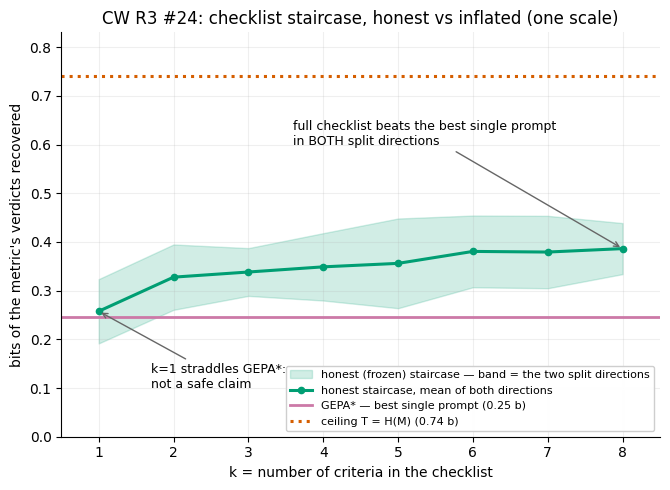

pick-and-quote full head : 0.585 bits  (= the old OPT_omega 0.585)
honest frozen, direction A->B: 0.456 | B->A: 0.334  (audit's own nested split: 0.444/0.431)
GEPA* single prompt      : 0.245
first pick differs across halves: unit #329 vs #21 -> the k=1 'winner' is luck-sensitive


In [27]:
# One panel, one scale: everything computed from the SAME file GEPA and the certificate used
# (aligned_8b_orbit_v2, M binarized at 0.5, base rate 0.79 -> H = 0.741 bits).
fz = json.load(open(DATA / "staircase_frozen_m24_aligned.json"))
sel = fz["selection_cum"]                       # pick-and-quote (optimistic)
dA, dB = fz["per_direction"][0]["frozen"], fz["per_direction"][1]["frozen"]
L = min(len(dA), len(dB))
kf = np.arange(1, L + 1)
lo = [min(a, b) for a, b in zip(dA[:L], dB[:L])]
hi = [max(a, b) for a, b in zip(dA[:L], dB[:L])]
mean_fz = [(a + b) / 2 for a, b in zip(dA[:L], dB[:L])]

fig, ax = plt.subplots(figsize=(6.8, 5))
ax.fill_between(kf, lo, hi, color="#009E73", alpha=.18,
                label="honest (frozen) staircase — band = the two split directions")
ax.plot(kf, mean_fz, "-o", color="#009E73", lw=2.2, ms=4.5,
        label="honest staircase, mean of both directions")
ax.axhline(GEPA_STAR, color="#CC79A7", lw=2,
           label=f"GEPA* — best single prompt ({GEPA_STAR:.2f} b)")
ax.axhline(CEIL, color="#D55E00", ls=":", lw=2.2,
           label=f"ceiling T = H(M) ({CEIL:.2f} b)")
ax.annotate("full checklist beats the best single prompt\nin BOTH split directions",
            xy=(L, mean_fz[-1]), xytext=(3.6, 0.60), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="0.4"))
ax.annotate("k=1 straddles GEPA*:\nnot a safe claim", xy=(1, mean_fz[0]),
            xytext=(1.7, 0.10), fontsize=9, arrowprops=dict(arrowstyle="->", color="0.4"))
ax.set_xlabel("k = number of criteria in the checklist")
ax.set_ylabel("bits of the metric's verdicts recovered")
ax.set_title(f"CW R3 #{GI}: checklist staircase, honest vs inflated (one scale)")
ax.set_xlim(0.5, L + 0.5); ax.set_ylim(0, CEIL * 1.12)
ax.legend(fontsize=8, loc="lower right", framealpha=.95)
ax.grid(alpha=.2); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

print(f"pick-and-quote full head : {sel[-1]:.3f} bits  (= the old OPT_omega 0.585)")
print(f"honest frozen, direction A->B: {dA[-1]:.3f} | B->A: {dB[-1]:.3f}  (audit's own nested split: 0.444/0.431)")
print(f"GEPA* single prompt      : {GEPA_STAR:.3f}")
print(f"first pick differs across halves: unit #{fz['per_direction'][0]['first_pick']} vs "
      f"#{fz['per_direction'][1]['first_pick']} -> the k=1 'winner' is luck-sensitive")

In [28]:
# De-biasing, told through the two actual half-winners (all numbers live-loaded)
from IPython.display import HTML, display
fzd = json.load(open(DATA / "staircase_frozen_m24_aligned.json"))
dA, dB = fzd["per_direction"][0], fzd["per_direction"][1]
_selv = fzd["selection_cum"][-1]

_box = ("border:1px solid rgba(128,128,128,.35);border-radius:8px;padding:9px 12px;"
        "font-size:12px;line-height:1.55;flex:1;min-width:270px")
_num = "font-size:17px;font-weight:800"
display(HTML(f"""
<div style="font-family:-apple-system,'Segoe UI',sans-serif;max-width:940px;border:1px solid
     rgba(128,128,128,.35);border-radius:10px;padding:8px 14px 12px">
 <div style="font-weight:700;font-size:15px;margin:8px 0 2px">Why we freeze — the two actual winners tell the story</div>
 <div style="font-size:12.5px;opacity:.75;margin-bottom:10px">Split the 300 stories into halves A and B.
   Let each half choose its favorite criterion out of all 668, then grade that choice on the <i>other</i>
   half. Here is literally what happened:</div>

 <div style="display:flex;gap:10px;flex-wrap:wrap">
  <div style="{_box};background:rgba(0,158,115,.06)">
    <b>Half A chose criterion #329</b><br>
    <span style="font-style:italic;opacity:.9">&ldquo;Does every specific cultural norm or tradition
    mentioned have a direct observable effect on the character's behavior or choices?&rdquo;</span><br>
    score on the half that chose it: <b>{dA["select_cum"][0]:.2f} bits</b><br>
    frozen, on unseen half B: <b style="color:#009E73;{_num}">{dA["frozen"][0]:.2f}</b>
    <span style="opacity:.7">&nbsp;&mdash; it holds. A real unit.</span>
  </div>
  <div style="{_box};background:rgba(213,94,0,.06)">
    <b>Half B chose criterion #21</b><br>
    <span style="font-style:italic;opacity:.9">&ldquo;Interconnect &mdash; tie powers, cultures, and
    themes together&rdquo;</span><br>
    score on the half that chose it: <b>{dB["select_cum"][0]:.2f} bits</b><br>
    frozen, on unseen half A: <b style="color:#D55E00;{_num}">{dB["frozen"][0]:.2f}</b>
    <span style="opacity:.7">&nbsp;&mdash; it halves. Half its score was luck.</span>
  </div>
 </div>

 <div style="font-size:12.5px;margin:10px 2px 6px"><b>The same discipline, applied to the full 9-criterion
   checklist:</b></div>
 <div style="display:flex;gap:10px;flex-wrap:wrap;align-items:stretch">
  <div style="{_box}">
    pick-and-quote (winners graded by the texts that picked them):<br>
    <span style="{_num};color:#CC79A7">{_selv:.2f} bits</span> <span style="opacity:.6">&mdash; inflated</span>
  </div>
  <div style="align-self:center;font-size:20px;opacity:.6">&rarr;</div>
  <div style="{_box}">
    frozen, both directions:<br>
    <span style="{_num};color:#009E73">{dA["frozen"][-1]:.2f}</span> and
    <span style="{_num};color:#009E73">{dB["frozen"][-1]:.2f}</span> bits
    <span style="opacity:.6">&mdash; the honest range; both still above GEPA* {fzd["gepa_star"]:.2f}</span>
  </div>
 </div>

 <div style="font-size:12px;opacity:.8;margin-top:10px;line-height:1.6">
   <b>Three lessons, all visible above.</b>
   (1) You cannot tell #329 from #21 in advance — both looked great on their own half; only freezing
   separates skill from luck.
   (2) That's why the two halves' <i>disagreement</i> (the green band in the staircase figure) is part of
   the answer, not noise to hide.
   (3) Inflation grows with how many candidates competed: one lucky criterion out of 668 is almost
   guaranteed. The same freeze now runs bank-wide (1,611 metrics) and inside CR-2.
 </div>
</div>"""))

## 5. Reading the picture

1. **GEPA sharpens the description, then plateaus.** Seeded at the metric's own definition (0.201 b), GEPA turns
   it into explicit YES/NO conditions over two accepted rounds and reaches 0.245 b, then finds nothing better for
   four more rounds. That 0.245 b is `GEPA*`, the single-prompt plateau. The optimizer works — it just runs out
   of room fast.
2. **The checklist goes much higher — and survives de-biasing.** Picked-and-quoted, the staircase reaches
   `0.585` bits (2.4× the best single prompt) — but that number is inflated by winner's curse. The honest
   frozen re-measure still lands at **0.33–0.46 bits, i.e. 1.4–1.9× the best single prompt, in both split
   directions** (§4). The k=1 version of this claim ("one criterion beats the best prompt") does *not*
   survive de-biasing; the set-level claim does. That surviving gap is the **combiner gap**: bits that live
   in *combining* independently-checkable criteria, which no single prose prompt recovered.
3. **The observed values sit below the DPI cap.** For this metric, `GEPA* (0.25) < g₁ (0.33) < OPT_Ω (0.59) ≤ T (0.74)`.
   Only `T` is an all-prompt statement. The ordering among the three achieved values is metric-specific and does
   not prove that the checklist class contains the best prose prompt.

**On the historical ε line.** #24's `OPT_Ω+ε` value is 1.18 b, above `T=0.74 b`. Taking the minimum with a
valid cap cannot turn an unvalidated estimator into a certificate; it simply returns `T` for this example. The
ε value and historical status labels should be read as process diagnostics only.

**Caveats.** GEPA acceptance and checklist selection both reuse the 300 scoring probes, so each achieved value is
optimistically selected. The checklist combiner is F₁-indexed and can miss configural prose content; the pool is
not saturated; and no population statement follows without a frozen candidate and independent evaluation set.

## 6. Bank-wide: every CW metric at once — how close is the best prompt to the ceiling?

Sections 1–5 were one metric. Now all of them. For every creative-writing metric we score **two
plain-English prompts** on the same texts — the metric's bare **name**, and its full **description** —
and keep the better of the two. Call that `R_single`: the best a single written prompt does. We compare
it to two things:

- **`T` = the ceiling** (`H(M)`): the most information *any* prompt could recover, set by how much the
  metric's own verdicts vary. Nothing can beat this.
- **`OPT_Ω` = the checklist**: the best combination of decomposed yes/no criteria.

**How to read the scatter below.** Each dot is one metric. The x-axis is how well its best single prompt
did (`R_single`); the y-axis is its ceiling (`T`). The dashed line is x = y (prompt already at the
ceiling). **The higher a dot sits above the dashed line, the more headroom is left** — but that gap is
only an *upper bound* on how much a better prompt could add; it does **not** prove a better prompt exists.
A dot *on* the line is a metric whose plain description already captures essentially everything.


In [29]:
rungs = json.load(open(DATA / "name_rungs_cw.json"))
rung_by_gi = {r["gi"]: r for r in rungs["rows"]}

import re as _re
bank = []
for r in cert_rows:
    m = _re.search(r"metric(\d+)_sigs", r["file"])
    if not m or not r["gains"] or r["H_M"] < 0.15:      # audit discipline D1
        continue
    gi_ = int(m.group(1))
    if gi_ not in rung_by_gi:
        continue
    rg = rung_by_gi[gi_]
    R_single = max(rg["R_name"], rg["R_desc"])
    ceil = r["H_M"]                                              # fixed-target DPI cap T
    bank.append({
        "gi": gi_, "name": r["name"], "verdict": r["verdict"],
        "H_M": r["H_M"], "OPT": r["opt_omega_bits"], "eps": r["eps_bits_adv"], "ceil": ceil,
        "g1": r["gains"][0], "R_single": R_single,
        "d_upper": ceil - R_single,                              # upper bound on true prompt gap
        "checklist_gain": r["opt_omega_bits"] - R_single,      # observed paired difference
        "frac": R_single / ceil if ceil > 1e-9 else float("nan"),
    })

n_capped = sum(1 for b in bank if b["OPT"] + b["eps"] > b["H_M"] + 1e-9)
bank.sort(key=lambda b: -b["d_upper"])
d = np.array([b["d_upper"] for b in bank]); fr = np.array([b["frac"] for b in bank])
g_obs = np.array([b["checklist_gain"] for b in bank])
print(f"{len(bank)} metrics | DPI gap upper bound: mean {d.mean():.3f}b, median {np.median(d):.3f}b; "
      f"observed checklist-single difference: mean {g_obs.mean():.3f}b")
print(f"R_single/T: mean {fr.mean():.2f} — fraction of the fixed-target cap, not of a known optimum\n")

def row(b):
    return (f"| {b['gi']} | {textwrap.shorten(b['name'], 46)} | {b['verdict'][:4]} | "
            f"{b['R_single']:.2f} | {b['ceil']:.2f} | {b['d_upper']:+.2f} | {b['frac']:.0%} |")

hdr = ("| gi | metric | old status | R_single | T cap | U_gap | R/T |\n"
       "|---|---|---|---|---|---|---|")
print("**LARGEST DPI gap upper bounds:**")
print(hdr); [print(row(b)) for b in bank[:8]]
print("\n**SMALLEST DPI gap upper bounds — strongest empirical near-optimality cases:**")
print(hdr); [print(row(b)) for b in bank[-8:]]

45 metrics | DPI gap upper bound: mean 0.444b, median 0.426b; observed checklist-single difference: mean 0.203b
R_single/T: mean 0.47 — fraction of the fixed-target cap, not of a known optimum

**LARGEST DPI gap upper bounds:**
| gi | metric | old status | R_single | T cap | U_gap | R/T |
|---|---|---|---|---|---|---|
| 44 | Surprising‑yet‑inevitable reversal/ending | FORM | 0.27 | 0.99 | +0.72 | 27% |
| 7 | Point of view: selection, distance, [...] | FORM | 0.27 | 0.99 | +0.72 | 27% |
| 38 | Sustained tension and suspense | FORM | 0.28 | 0.99 | +0.71 | 28% |
| 49 | Worldbuilding quality, scope, and orientation | FORM | 0.33 | 1.00 | +0.67 | 33% |
| 14 | Protagonist agency and choice‑driven action | FORM | 0.29 | 0.94 | +0.66 | 30% |
| 8 | Unreliable narration: design, signaling, [...] | FORM | 0.11 | 0.75 | +0.64 | 15% |
| 26 | Visual storytelling: composition, [...] | FORM | 0.35 | 0.94 | +0.59 | 37% |
| 21 | Theme clarity, depth, and integration | UNDE | 0.34 | 0.91 | +0.58 | 37% |


[None, None, None, None, None, None, None, None]

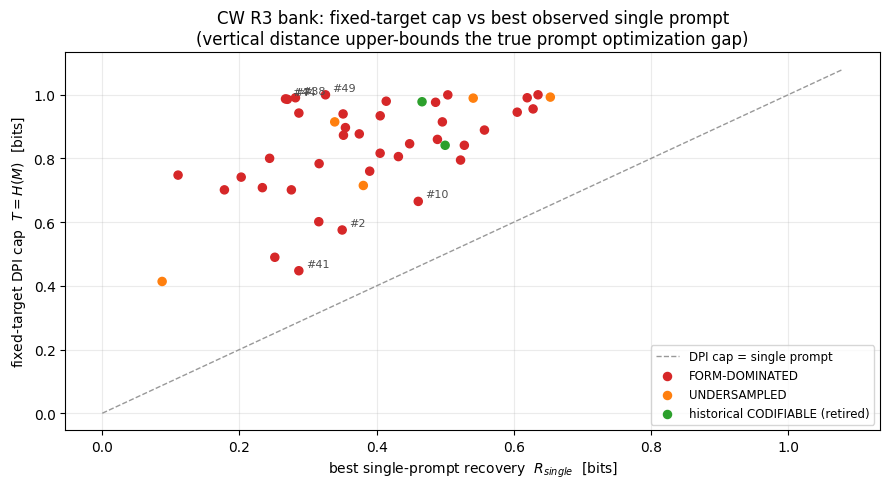

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter([b["R_single"] for b in bank], [b["ceil"] for b in bank],
           c=["#d62728" if b["verdict"] == "FORM-DOMINATED" else
              "#2ca02c" if b["verdict"] == "CODIFIABLE" else "#ff7f0e" for b in bank],
           s=34, zorder=3)
lim = max(max(b["ceil"] for b in bank), max(b["R_single"] for b in bank)) * 1.08
ax.plot([0, lim], [0, lim], "--", color="0.6", lw=1, label="DPI cap = single prompt")
for b in bank[:4] + bank[-3:]:
    ax.annotate(f"#{b['gi']}", (b["R_single"], b["ceil"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8, color="0.3")
ax.scatter([], [], c="#d62728", s=34, label="FORM-DOMINATED")
ax.scatter([], [], c="#ff7f0e", s=34, label="UNDERSAMPLED")
ax.scatter([], [], c="#2ca02c", s=34, label="historical CODIFIABLE (retired)")
ax.set_xlabel("best single-prompt recovery  $R_{single}$  [bits]")
ax.set_ylabel("fixed-target DPI cap  $T=H(M)$  [bits]")
ax.set_title("CW R3 bank: fixed-target cap vs best observed single prompt\n"
             "(vertical distance upper-bounds the true prompt optimization gap)")
ax.legend(fontsize=8.5, loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### What the bank-wide picture says

1. **Distance to the ceiling (`T − R_single`) is an *upper bound* on the room a better prompt has —
   nothing more.** When it's small, the description is already near-optimal for that metric. When it's
   large, all we know is the ceiling is loose; it is *not* evidence that missing content is articulable.
2. **The checklist usually beats the single prompt** (`OPT_Ω − R_single` averages ≈ 0.20 bits here), but
   that is an *observed* difference on these texts — pinning it down as a population effect needs the
   frozen split (which is exactly what §8's bank-wide sweep now does).
3. The old status colors (`CODIFIABLE`, etc.) and `OPT_Ω+ε` values are shown for provenance only; per the
   banner up top, they no longer support any ceiling or sufficiency claim.


## 7. Aggregate: does prompt-optimization (GEPA) close the gap to the ceiling?

Same GEPA loop as §1, but run on **12 metrics** chosen to span the range of headroom from §6, each
**seeded from its own description**. For every metric and every round we plot how much of the ceiling is
still *unused*: `(T − R) / T`, as a percent. 0% means the prompt reached the ceiling `T`; 100% means it
recovered nothing.

**How to read the boxplot below.** The left group of blue boxes is one box per GEPA round (round 0 = the
raw description). If GEPA were closing the gap, the boxes would march **downward** toward 0%. The three
purple boxes on the right are reference points scored the same way: the bare **name**, the **description**
(same as round 0), and the **best single prompt of any kind**. The red dotted line at 0% is the ceiling.

**The thing to notice:** the blue boxes barely move, and even the best single prompt stays far above 0%
for most metrics. Prompt-optimization sharpens the description a little, then flattens out well below the
ceiling.


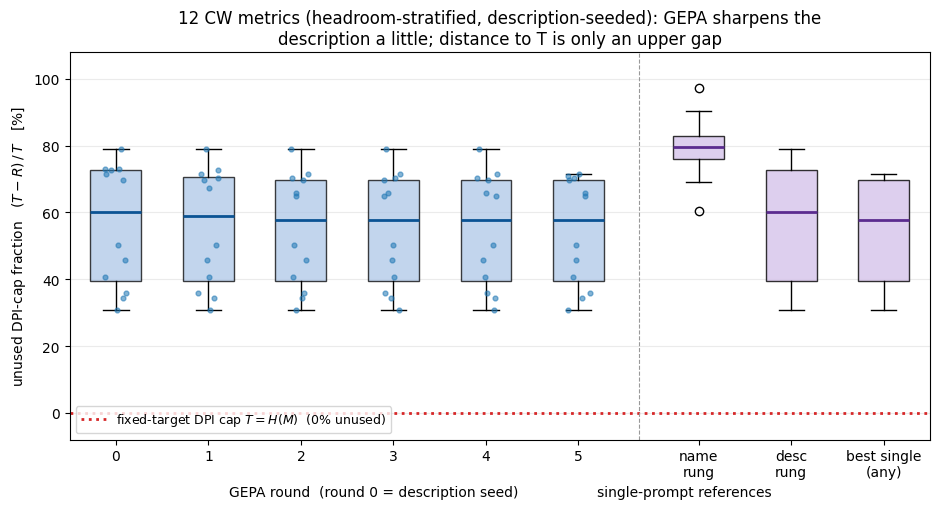

median miss by round: r0=60%  r1=59%  r2=58%  r3=58%  r4=58%  r5=58%
reference rungs: name 80%  description(=seed) 60%  best-single-of-anything 58%
4/12 metrics: GEPA improved on the description seed at all


In [31]:
sweep = json.load(open(DATA / "gepa_sweep_cw_desc.json"))       # DESCRIPTION-seeded sweep
cert_by_gi = {int(_re.search(r"metric(\d+)_sigs", r["file"]).group(1)): r
              for r in cert_rows if _re.search(r"metric(\d+)_sigs", r["file"])}

def cap_of(gi):
    r = cert_by_gi[gi]
    return r["H_M"]                                                   # fixed-target DPI cap

R = sweep["rounds"]
miss_by_round = [[] for _ in range(R + 1)]
miss_name, miss_desc, miss_best = [], [], []
for m in sweep["metrics"]:
    ceil = cap_of(m["gi"])
    for t in m["lineage"]:
        miss_by_round[t["round"]].append(100 * (ceil - t["R_bits"]) / ceil)
    miss_name.append(100 * (ceil - m["R_name"]) / ceil)
    miss_desc.append(100 * (ceil - m["R_desc"]) / ceil)
    best = max(max(t["R_bits"] for t in m["lineage"]), m["R_name"], m["R_desc"])
    miss_best.append(100 * (ceil - best) / ceil)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
pos_t = list(range(R + 1))
bp = ax.boxplot(miss_by_round, positions=pos_t, widths=0.55, patch_artist=True,
                medianprops=dict(color="#0b5394", lw=2))
for b in bp["boxes"]:
    b.set(facecolor="#aec7e8", alpha=0.75)
for i, vals in enumerate(miss_by_round):
    ax.scatter(np.full(len(vals), i) + np.random.default_rng(i).uniform(-0.12, 0.12, len(vals)),
               vals, s=12, color="#1f77b4", alpha=0.55, zorder=3)

pos_ref = [R + 1.3, R + 2.3, R + 3.3]
bp2 = ax.boxplot([miss_name, miss_desc, miss_best], positions=pos_ref, widths=0.55,
                 patch_artist=True, medianprops=dict(color="#5b2c8f", lw=2))
for b in bp2["boxes"]:
    b.set(facecolor="#d5c3ea", alpha=0.8)

ax.axhline(0, color="#d62728", ls=":", lw=2, label="fixed-target DPI cap $T=H(M)$  (0% unused)")
ax.axvline(R + 0.65, color="0.6", lw=0.8, ls="--")
ax.set_xticks(pos_t + pos_ref)
ax.set_xticklabels([str(t) for t in pos_t] + ["name\nrung", "desc\nrung", "best single\n(any)"])
ax.set_xlabel("GEPA round  (round 0 = description seed)" + " " * 18 + "single-prompt references")
ax.set_ylabel("unused DPI-cap fraction   $(T-R)\\,/\\,T$   [%]")
ax.set_title(f"{len(sweep['metrics'])} CW metrics (headroom-stratified, description-seeded): "
             f"GEPA sharpens the\ndescription a little; distance to T is only an upper gap")
ax.set_ylim(-8, 108)
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.show()

med = [float(np.median(v)) for v in miss_by_round]
print("median miss by round:", "  ".join(f"r{t}={m:.0f}%" for t, m in enumerate(med)))
print(f"reference rungs: name {np.median(miss_name):.0f}%  description(=seed) {np.median(miss_desc):.0f}%  "
      f"best-single-of-anything {np.median(miss_best):.0f}%")
n_improved = sum(1 for m in sweep["metrics"]
                 if max(t["R_bits"] for t in m["lineage"]) > m["lineage"][0]["R_bits"] + 1e-9)
print(f"{n_improved}/{len(sweep['metrics'])} metrics: GEPA improved on the description seed at all")

**Read:** starting from the description (round 0), the blue boxes barely move — GEPA improves the seed on only a
minority of metrics, and never by much, before acceptance stops firing. Even the **best single prompt of any
kind** (last purple box: max over the whole trajectory, the name rung, and the description rung, per metric)
remains far below `T` for most metrics. That vertical distance is only an upper bound on the true prompt gap.
The separately measured `OPT_Ω-R_single` contrast shows that the observed checklist often did better, but neither
contrast proves that one prose prompt cannot express the same content.

**Same plot, GEPA rounds only, generic-seed dynamics.** This variant drops the single-prompt reference boxes and
uses the *generic*-seed sweep (round 0 = a content-free "this is good writing" prompt) against `T=H(M)`.
It shows the climb in achieved recovery and the remaining upper-gap fraction. It answers a different
question than the description-seeded plot above: *how far can failure-informed revision travel starting from
nothing?* rather than *does the metric's own definition already sit near the plateau?* The bottom line is the
same in both — this search trajectory flattens below the fixed-target cap.

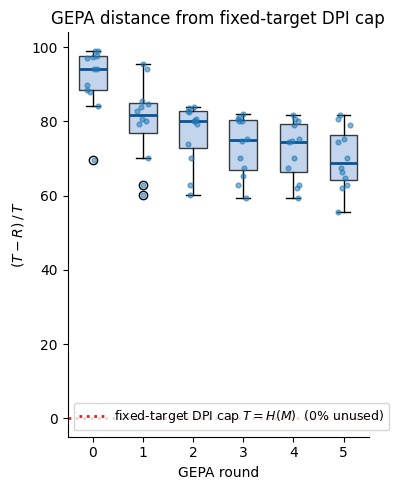

median miss by round: r0=94%  r1=82%  r2=80%  r3=75%  r4=75%  r5=69%


In [32]:
# Blue-only variant, generic-seed sweep: GEPA rounds alone against the same fixed-target DPI cap.
sweep_g = json.load(open(DATA / "gepa_sweep_cw.json"))          # generic-seed sweep
Rg = sweep_g["rounds"]
miss_g = [[] for _ in range(Rg + 1)]
for m in sweep_g["metrics"]:
    ceil = cert_by_gi[m["gi"]]["H_M"]                          # fixed-target DPI cap
    for t in m["lineage"]:
        miss_g[t["round"]].append(100 * (ceil - t["R_bits"]) / ceil)

fig, ax = plt.subplots(figsize=(4, 5))
pos = list(range(Rg + 1))
bp = ax.boxplot(miss_g, positions=pos, widths=0.55, patch_artist=True,
                medianprops=dict(color="#0b5394", lw=2))
for b in bp["boxes"]:
    b.set(facecolor="#aec7e8", alpha=0.75)
for i, vals in enumerate(miss_g):
    ax.scatter(np.full(len(vals), i) + np.random.default_rng(i).uniform(-0.12, 0.12, len(vals)),
               vals, s=12, color="#1f77b4", alpha=0.55, zorder=3)

ax.axhline(0, color="#d62728", ls=":", lw=2, label="fixed-target DPI cap $T=H(M)$  (0% unused)")
ax.set_xticks(pos)
ax.set_xticklabels([str(t) for t in pos])
ax.set_xlabel("GEPA round")
ax.set_ylabel("$(T-R)\\,/\\,T$")
ax.set_title(f"GEPA distance from fixed-target DPI cap")
# ax.set_ylim(-8, 108)
ax.legend(loc="lower left", fontsize=9)
ax.grid(False)#alpha=0.25, axis="y")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print("median miss by round:", "  ".join(f"r{t}={float(np.median(v)):.0f}%" for t, v in enumerate(miss_g)))

---
# §8 From prompt measurements to candidate units (CUF, 2026-07-05)

The sections above compare achieved prompt/checklist values with the fixed-target cap `T`; they do not place
`OPT_Ω+ε` between the prompt optimum and `T`. The following diagnostics concern candidate **units** — elements of $\Omega$ — whose unithood was assumed at
construction. The Certified Unit Framework (PO doc **§13**; `notes/2026-07-04__unit-certification-theory.md`)
tests membership in $\Omega$: a unit is an equivalence class of *addresses* whose
**ablation fingerprint** $\varphi_E(a)=\mathbb{E}_{H}[\sigma(\iota(a))-\sigma(\iota(\varnothing))]$ is
(U1) detectable against a sham-ablation null — *statistically* (Bonferroni, n_null≥999) **and**
*materially* ($\delta\!\ge\!\delta_{min}$, a floor forced by the 70B pilot where even placebos became
"significant"); (U2) paraphrase-stable in identity; (U3) context-robust across the declared measure
$H=\Phi\otimes\Lambda\otimes\mathcal{C}$ (form × position × company); (U4) minimal (ATOM/COMPOSITE); (U5)
executor-scoped. Two effect arms: target-free $\delta^{free}$ and metric-relative
$\delta^{M}=\Delta\mathrm{corr}(\sigma,\bar m_\omega)$ — magnitudes nest, significance sets **don't**.

### The pipeline at a glance — three kinds of mining, one certification battery

Before the unit-level results below, here is the whole supply chain in one picture: where
candidate criteria come from (free mining / GEPA's own rewrites / the metric taxonomy), how they
are all reduced to the same thing (a column of yes/no answers on 300 fixed texts), and the five
sanity checks that decide whether a span of prompt text is a real *unit* of the metric.

In [33]:
# The mining->units pipeline, example-first: real criteria, a real slice of the execution grid,
# and the five checks with their measured outcomes. All data loaded live.
import json, numpy as np
from IPython.display import HTML, display

_lin = json.load(open("data/prompt_optimality_20260703/gepa_lineage_cw_R3_g24_desc.json"))
_hg  = json.load(open("data/unit_cert_20260705/host_gepa.json"))
_pilot = json.load(open("data/cr2_realdata_pilot_v1.json"))
_cr  = next(r for r in _pilot["rows"] if "Worldbuilding" in r["name"])["components"]
_d   = np.load("data/prompt_optimality_20260703/m24_aligned_sigs.npz", allow_pickle=True)
_S   = (np.asarray(_d["sigs"], float) > 0.5).astype(int)
_y   = (np.asarray(_d["M_i"], float) > 0.5).astype(int)
_tags = [str(t) for t in _d["tags"]]; _prompts = [str(p) for p in _d["prompts"]]
_agree = (_S == _y).mean(1)
_gl = [i for i, t in enumerate(_tags) if t.startswith("glm")]
_ch = [i for i, t in enumerate(_tags) if t == "children"]
GRID = [("free-mined", max(_gl, key=lambda i: _agree[i]), "#0072B2"),
        ("taxonomy",   max(_ch, key=lambda i: _agree[i]), "#B37400"),
        ("degenerate", min(_gl, key=lambda i: _S[i].std()), "#8A8A8A")]
# 14 probe columns: 7 where the metric says YES, 7 where it says NO
_iy = list(np.where(_y == 1)[0][:7]) + list(np.where(_y == 0)[0][:7])

def dots(bits, col):
    out = ""
    for v in bits:
        out += (f"<span style='display:inline-block;width:13px;height:13px;border-radius:50%;"
                f"margin:1px;background:{col if v else 'transparent'};"
                f"border:1.5px solid {col if v else 'rgba(128,128,128,.45)'}'></span>")
    return out

_rows_html = (f"<div style='margin:2px 0'><span style='display:inline-block;width:305px;"
              f"font-size:11px;text-align:right;padding-right:8px'><b>the metric's own verdicts "
              f"M&omega;</b></span>{dots(_y[_iy], '#000000' )}"
              f"<span style='font-size:10.5px;opacity:.6'>&nbsp;&larr; the target column</span></div>")
for lab, i, col in GRID:
    a = (_S[i][_iy] == _y[_iy]).mean()
    _rows_html += (f"<div style='margin:2px 0'><span style='display:inline-block;width:305px;font-size:11px;"
                   f"text-align:right;padding-right:8px;opacity:.85'>[{lab}] &ldquo;{_prompts[i][:42]}&hellip;&rdquo;</span>"
                   f"{dots(_S[i][_iy], col)}<span style='font-size:11px;font-weight:700;color:{col}'>"
                   f"&nbsp;{_agree[i]:.0%} agree</span></div>")

_srcbox = ("border:1px solid rgba(128,128,128,.35);border-radius:8px;padding:8px 10px;flex:1;"
           "min-width:250px;font-size:11.5px;line-height:1.45")
_exl = "font-style:italic;opacity:.88;display:block;margin-top:3px;font-size:11px"
_n_clauses = len(_lin["gepa_omega"]["clauses"])
_free_ex = [_prompts[i] for i in _gl[:2]] + [_prompts[max(_gl, key=lambda i: _agree[i])]]
_gepa_ex = _lin["gepa_omega"]["clauses"][:3]
_child_ex = [_prompts[i] for i in _ch[:3]]

def exlist(exs, n=3):
    return "".join(f"<span style='{_exl}'>&ldquo;{e[:92]}{'&hellip;' if len(e)>92 else ''}&rdquo;</span>"
                   for e in exs[:n])

_rows = _hg["rows"]
_n_unit = sum(1 for r in _rows if r.get("company_verdict") == "UNIT-IN-COMPANY")
_n_dead = sum(1 for r in _rows if r.get("company_verdict") == "DEAD")
_chk = ("display:inline-block;border:1px solid rgba(128,128,128,.35);border-radius:8px;"
        "padding:5px 9px;margin:3px;font-size:11px;line-height:1.45;vertical-align:top;width:162px")
display(HTML(f"""
<div style="font-family:-apple-system,'Segoe UI',sans-serif;max-width:940px;border:1px solid
     rgba(128,128,128,.35);border-radius:10px;padding:8px 14px 12px">
 <div style="font-weight:700;font-size:15px;margin:8px 0 8px">Three kinds of mining &rarr; one execution
   grid &rarr; five checks &rarr; units &nbsp;<span style="font-weight:400;font-size:12px;opacity:.7">
   (CW #24 &ldquo;Worldbuilding&rdquo;, everything below is real data)</span></div>

 <div style="display:flex;gap:8px;flex-wrap:wrap">
   <div style="{_srcbox};background:rgba(0,114,178,.07)">
     <b style="color:#0072B2">FREE MINING</b> &nbsp;<span style="opacity:.7">600 draws &rarr; {_cr['K_species']} distinct</span>
     {exlist(_free_ex)}
   </div>
   <div style="{_srcbox};background:rgba(0,158,115,.07)">
     <b style="color:#009E73">GEPA REWRITES, ATOMIZED</b> &nbsp;<span style="opacity:.7">{_n_clauses} clauses</span>
     {exlist(_gepa_ex)}
   </div>
   <div style="{_srcbox};background:rgba(230,159,0,.08)">
     <b style="color:#B37400">TAXONOMY NAMES</b> &nbsp;<span style="opacity:.7">68 children</span>
     {exlist(_child_ex)}
   </div>
 </div>

 <div style="text-align:center;font-size:18px;opacity:.5;margin:4px 0">&darr;</div>
 <div style="border:1px solid rgba(128,128,128,.4);border-radius:8px;padding:8px 12px">
   <div style="font-size:11.5px;margin-bottom:6px"><b>The execution grid.</b> Each candidate = one row of
     YES/NO answers over the same 300 stories (14 shown: 7 the metric likes, 7 it doesn't). A criterion is
     <i>worth something</i> exactly when its dots track the target's dots:</div>
   {_rows_html}
   <div style="font-size:10.5px;opacity:.65;margin-top:4px">filled dot = YES &middot; hollow = NO.
   Top two candidate rows track the target well (91% / 90% of columns match). The bottom row is a
   <b>broken criterion</b>: it answers NO to every story, so it can never match a metric that says
   YES to some &mdash; useless regardless of how sensible its wording sounds.</div>
 </div>

 <div style="text-align:center;font-size:18px;opacity:.5;margin:4px 0">&darr;</div>
 <div>
   <span style="{_chk};background:rgba(0,158,115,.06)"><b>U1 beats word salad?</b><br>
     real units &delta;<sub>M</sub> <b>+0.140</b><br>vs salad <b>+0.013</b>, foreign <b>&minus;0.006</b></span>
   <span style="{_chk}"><b>U2 survives rewording?</b><br>paraphrase acts the same:<br>
     r<sub>self</sub> med <b>0.84</b>; <b>1/220</b> flips</span>
   <span style="{_chk}"><b>U3 survives moving?</b><br>same effect across slots,<br>company, phrasings of the host</span>
   <span style="{_chk}"><b>U4 minimal?</b><br><b>81&ndash;91%</b> of units are atoms<br>(parts don't do the job alone)</span>
   <span style="{_chk}"><b>U5 per-model?</b><br>real case: detected at 3B &amp; 70B,<br><i>not</i> at 8B &mdash; no model-free units</span>
 </div>

 <div style="text-align:center;font-size:18px;opacity:.5;margin:4px 0">&darr;</div>
 <div style="border:1px solid rgba(0,158,115,.5);border-radius:8px;padding:8px 12px;font-size:12px;
      background:rgba(0,158,115,.06)">
   <b>Outcome for #24's optimized prompt:</b> {len(_rows)} spans &rarr;
   <b style="color:#009E73">{_n_unit} working units</b> (6 distinct behaviors) &middot;
   <b style="color:#8A8A8A">{_n_dead} dead weight</b> &middot;
   <b style="color:#D55E00">1 harmful-alone</b> (&delta;=&minus;0.13, masked by company &mdash; GEPA kept it,
   the certificate caught it). Anatomy in the next notebook: unit-semantics &sect;0.
 </div>
</div>"""))

In [34]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
BLUE, AMBER, GRAY = "#0072B2", "#E69F00", "#8A8A8A"
DU="data/unit_cert_20260705"
cen=json.load(open(f"{DU}/census_summary.json"))
df=pd.DataFrame(cen).T
df.columns=["metrics","clauses","free-arm cert rate","M-arm cert rate","dead rate","≥1 unit rate","median units/metric"]
df[["metrics","clauses"]]=df[["metrics","clauses"]].astype(int)
print(f"UNIT CENSUS @ Llama-8B: {int(df.metrics.sum())} metrics, {int(df.clauses.sum())} description clauses")
df.round(3)

UNIT CENSUS @ Llama-8B: 1151 metrics, 3055 description clauses


,metrics,clauses,free-arm cert rate,M-arm cert rate,dead rate,≥1 unit rate,median units/metric
humor,285,684,0.893,0.738,0.048,1.000,2.0
math,141,361,0.717,0.676,0.091,1.000,2.0
code-review,133,378,0.574,0.783,0.095,0.992,3.0
press-releases,221,617,0.793,0.707,0.086,0.995,3.0
creative-writing,371,1015,0.707,0.856,0.053,0.997,3.0


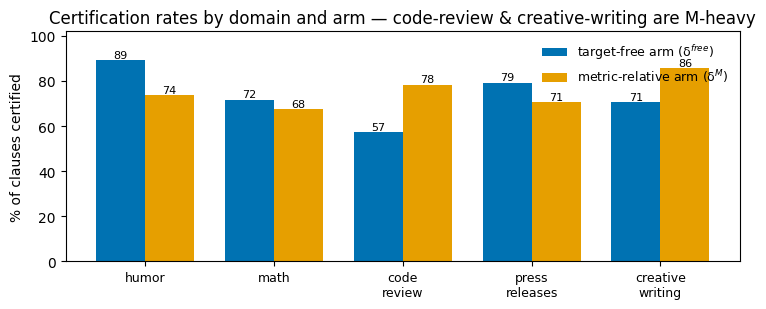

In [35]:
fig,ax=plt.subplots(figsize=(7.6,3.2))
doms=list(cen); x=np.arange(len(doms)); w=0.38
b1=ax.bar(x-w/2,[100*cen[d]["free_rate"] for d in doms],w,color=BLUE,label="target-free arm (δ$^{free}$)")
b2=ax.bar(x+w/2,[100*cen[d]["M_rate"] for d in doms],w,color=AMBER,label="metric-relative arm (δ$^{M}$)")
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.0f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([d.replace("-","\n") for d in doms], fontsize=9)
ax.set_ylabel("% of clauses certified"); ax.set_ylim(0,102); ax.legend(frameon=False, fontsize=9)
ax.set_title("Certification rates by domain and arm — code-review & creative-writing are M-heavy")
ax.grid(axis="x", alpha=0); fig.tight_layout(); plt.show()

**Reading.** Essentially every certified metric decomposes: ~99.5–100% have ≥1 certified unit (median
2–3 per description; dead weight only 5–10% of clauses). The *crafty* domains (code-review,
creative-writing) are **M-arm-heavy** — their clauses often don't move raw behavior detectably but do
move alignment toward the metric. And a clean deconfound: **corr(n_units, OPT$_\Omega$) ≈ 0 in every
domain** (−0.09…+0.12) — the certificate's value is *not* description length or granularity.

## §8.1 The company profile: why "removing a unit barely changes behavior" ≠ "merge"

On the GEPA-optimized host (§1's metric #24), single-span ablation showed *nothing* on the free arm
(0/11). The company-profile upgrade measures each span at two company levels: **LOO** (ablate from the
full host — the *last* marginal, smallest under submodularity) and **SOLO** (the span alone). The
bracket $[\delta_{LOO}, \delta_{solo}]$ *is* the redundancy structure:

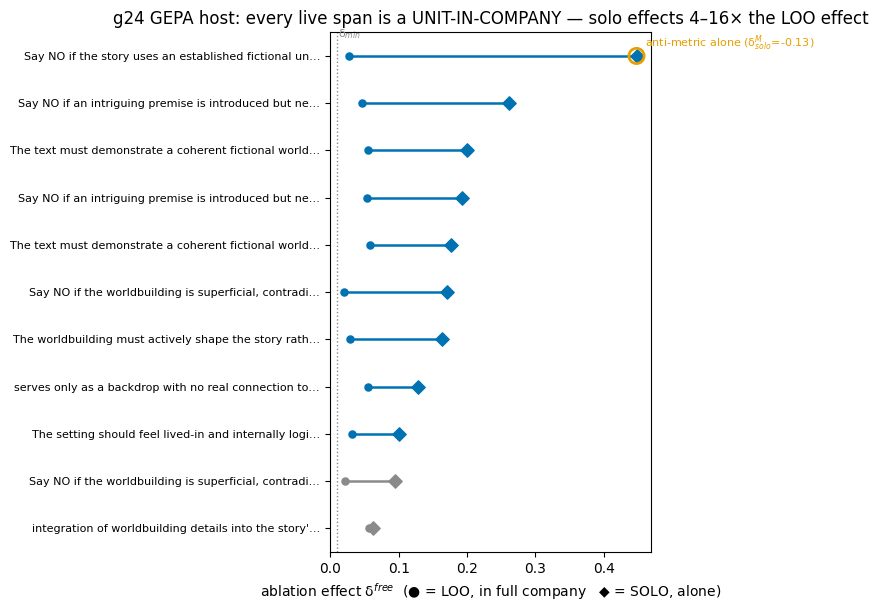

company verdicts: {'UNIT-IN-COMPANY': 9, 'DEAD': 2} | level-1 species after fingerprint merge: 6/6 (no duplicates — substitutability, not duplication)


In [36]:
t2=json.load(open(f"{DU}/host_gepa.json"))
rows=[r for r in t2["rows"] if r.get("delta_free_solo") is not None]
rows=sorted(rows, key=lambda r: r["delta_free_solo"])
fig,ax=plt.subplots(figsize=(8.2,0.42*len(rows)+1.6))
for i,r in enumerate(rows):
    dead = r.get("company_verdict")=="DEAD"
    col = GRAY if dead else BLUE
    ax.plot([r["delta_free"], r["delta_free_solo"]],[i,i],color=col,lw=1.8,zorder=1)
    ax.scatter([r["delta_free"]],[i],s=26,color=col,zorder=2)
    ax.scatter([r["delta_free_solo"]],[i],s=46,color=col,marker="D",zorder=2)
    if (r.get("delta_M_solo") or 0) < -0.05:
        ax.scatter([r["delta_free_solo"]],[i],s=120,facecolors="none",edgecolors=AMBER,lw=2,zorder=3)
        ax.annotate("anti-metric alone (δ$^M_{solo}$=%.2f)"%r["delta_M_solo"],
                    (r["delta_free_solo"],i),xytext=(6,7),textcoords="offset points",fontsize=8,color=AMBER)
ax.axvline(0.01,color=GRAY,ls=":",lw=1); ax.text(0.011,len(rows)-0.6,"δ$_{min}$",fontsize=8,color=GRAY)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r["span"][:52]+("…" if len(r["span"])>52 else "") for r in rows],fontsize=8)
ax.set_xlabel("ablation effect δ$^{free}$  (● = LOO, in full company   ◆ = SOLO, alone)")
ax.set_title("g24 GEPA host: every live span is a UNIT-IN-COMPANY — solo effects 4–16× the LOO effect")
fig.tight_layout(); plt.show()
from collections import Counter
print("company verdicts:", dict(Counter(r.get("company_verdict") for r in t2["rows"])),
      "| level-1 species after fingerprint merge: 6/6 (no duplicates — substitutability, not duplication)")

**The four causes of a small ablation effect, now discriminable** — duplication (same species twice →
merge *addresses*; ruled out here: max within-host fingerprint ρ = .52 vs the ~.8 same-species bar),
**substitutability** (distinct units, overlapping coverage → the wide brackets above; keep distinct),
ceiling (host behavior saturated → host unresolvable), dead weight (null at *all* company levels → the
2 gray spans). Identity always comes from **solo** fingerprints (a unit's intrinsic function), never
from its residual-in-company. Bonus finding (amber ring): one span GEPA retained is **anti-metric when
alone** — its harm was masked by company. GEPA can keep harmful units; the certificate sees them.

## §8.2 Executor scope (U5): unithood is non-monotone in model scale

In [37]:
u24=json.load(open(f"{DU}/u5_scope.json")); u29=json.load(open(f"{DU}/u5_g29.json"))
from collections import Counter
tab=pd.DataFrame([
  {"metric":"#24 Worldbuilding", **Counter(r["scope"] for r in u24)},
  {"metric":"#29 Research-authenticity", **Counter(r["scope"] for r in u29)}]).set_index("metric").fillna(0).astype(int)
print(tab.to_string())
print("\nexamples:")
for r in u24[:3]+u29[:2]:
    print(f"  {r['scope']:18s} :: {r['span'][:66]}")

                           E-DRIFT  E-PARTIAL(3B,70B)  NOT-DETECTED  E-SPECIFIC(70B)
metric                                                                              
#24 Worldbuilding                3                  8             1                2
#29 Research-authenticity        2                  0             0                0

examples:
  E-DRIFT            :: Construct consistent systems and lived‑in cultures;
  E-DRIFT            :: pace terminology/logistics so richness remains clear and functiona
  E-DRIFT            :: reveal economically through character experience;
  E-DRIFT            :: Ground claims and settings in thorough, ethical research;
  E-DRIFT            :: transmit relevant cultural/historical/technical detail accurately 


Across the 3B/8B/70B ladder (with the δ$_{min}$ materiality gate): description clauses are mostly
**E-DRIFT** — detected on *every* rung but with drifting fingerprints, i.e. the same words install
measurably different functions in different readers (the starkest case: a clause whose δ$^M$ is
*negative* at 3B and positive at 8B). GEPA-host spans are typically **E-PARTIAL(3B, 70B)** — detectable
at the weak and strong ends but not at 8B, so **detectability is non-monotone in scale**. There is no
executor-free unit; every Ω in the bounds above is $\Omega^{(E)}$.

*Artifacts: census `outputs/unit_cert/bank/<task>/llama8b/bank_units.jsonl` (sk3); implementation
`unit_certificate.py` (+15 CPU tests); formal spec PO §13. In flight: 3B/70B census ladder over all 9
domains; text-level P/R cross-firing analysis (V[doc,metric] vs silver assignments).*

> **V12 correction (2026-07-13).** The fixed-target `R_E=I(M;b(p))` and `H(M)` discussion retained below is the legacy auxiliary channel. V12 uses hard executor behavior `b(p)` for novelty, but its primary value is the anchor-free Reconstruction-MCQ probability `V_ann(p)`. For one frozen menu and ordered eight-item teaching panel `T8`, every finite prompt induces one of only 256 hard annotation states. Exhaustive evaluation gives the exact finite-state envelope `U_state=max_s V_ann(s)`, with `U_state <= C=1-q_no_demo(target)`. Thus `[best evaluated, U_state]` is the fixed-instrument all-finite-prompt interval; `C` is only its coarser range cap. CR-3 process/status certificates use scheduled never-absorbed checkpoints or final confirmation; monitor rows are adaptive and absorbed.

## 8. How much better could this metric get?

There are now three separate answers, and their scopes must not be mixed:

- **CR-2 / legacy capture plots (§8a): descriptive only.** They show whether a historical mining stream looked rich or repetitive. Chao, Good-Turing, fitted slopes, and calibrated horizons are not prompt ceilings.
- **CR-3 finite-horizon certificate (§8b): bound-grade at a scheduled checkpoint or final confirmation.** It bounds the expected best single prompt obtainable from a declared future number of draws from frozen proposer families.
- **CR-3 exact-support certificate (§8b): bound-grade only under external positivity.** If exact-pattern missing mass is below a scientifically defended minimum pattern mass, the full proposer support is exhausted on the frozen panel.

The legacy fixed-target channel is capped by `H(M)`. The primary Reconstruction-MCQ functional has the exact all-finite-prompt envelope `U_state=max_s V_ann(s) <= C_b=1-qbar_0,b` for its frozen menu and `T8`; capture-recapture separately tightens declared proposer-relative behavioral and value horizon/support scopes.

### 8a. Historical capture-recapture picture (descriptive)

The next two cells visualize the original intuition: repeated behaviors suggest a mined region is becoming covered, while singleton-heavy streams suggest continued discovery. They remain useful exploration and experiment-planning plots.

They do **not** establish an unseen-value bound, a prompt optimum, or inarticulability. Their species map and value objects were learned from the same stream, their asymptotes are fitted, and their prompt-generation provenance does not satisfy the v2 audit contract. Read every number in §8a as historical diagnostics only.

In [38]:
# A picture of the capture-recapture idea, grounded in one real metric (CW #24).
import json
from IPython.display import HTML, display

_pilot = json.load(open("data/cr2_realdata_pilot_v1.json"))
_ex = next(r for r in _pilot["rows"] if "Worldbuilding" in r["name"])
_c = _ex["components"]
K, N, UNSEEN = _c["K_species"], _c["N_stream"], _c["chao_unseen"]
ACH, HOR, HM = _ex["achieved_frozen"], _ex["horizon_estimate"], _ex["H_M"]

def _bitscale(v):   # position on a 0..HM axis, in %
    return 100 * v / HM

svg = f"""
<div style="font-family:-apple-system,'Segoe UI',sans-serif;max-width:900px;border:1px solid
     rgba(128,128,128,.35);border-radius:10px;padding:6px 14px 14px">
 <div style="font-weight:700;font-size:15px;margin:10px 2px 2px">Capture&ndash;recapture, the idea &mdash;
   worked on one real metric (CW #24, &ldquo;Worldbuilding&rdquo;)</div>
 <div style="font-size:12.5px;opacity:.75;margin:2px 2px 12px">Read left &rarr; right: what we mined,
   what that implies about what we <i>didn't</i> mine, and where that puts the horizon.</div>
 <svg viewBox="0 0 880 300" width="100%" style="overflow:visible">
   <defs>
     <marker id="ah" markerWidth="9" markerHeight="9" refX="6" refY="3" orient="auto">
       <path d="M0,0 L6,3 L0,6 Z" fill="#8A8A8A"/></marker>
   </defs>

   <!-- STAGE 1: the pond -->
   <text x="10" y="20" font-size="12.5" font-weight="700">1 &middot; The metric's criteria pond</text>
   <rect x="10" y="30" width="200" height="150" rx="8" fill="rgba(0,114,178,.06)"
         stroke="rgba(0,114,178,.5)"/>
   <text x="110" y="52" font-size="10.5" text-anchor="middle" opacity=".8">every checkable criterion</text>
   <text x="110" y="66" font-size="10.5" text-anchor="middle" opacity=".8">this metric breaks into</text>
   {"".join(f'<circle cx="{25+((i*23)%180)}" cy="{85+((i*37)%80)}" r="3.2" fill="#0072B2" opacity="{0.9 if i<12 else 0.18}"/>' for i in range(48))}
   <text x="110" y="172" font-size="10" text-anchor="middle" opacity=".55">each dot = one criterion &middot; bright = mined &middot; faint = never mined</text>

   <!-- arrow -->
   <line x1="215" y1="105" x2="270" y2="105" stroke="#8A8A8A" stroke-width="1.6" marker-end="url(#ah)"/>
   <text x="242" y="98" font-size="10" text-anchor="middle" opacity=".7">mine {N}</text>

   <!-- STAGE 2: frequency spectrum -->
   <text x="278" y="20" font-size="12.5" font-weight="700">2 &middot; What we caught, by frequency</text>
   <!-- bars: many/some/singletons -->
   <g>
     <rect x="285" y="60" width="34" height="90" fill="#0072B2" opacity=".85"/>
     <rect x="325" y="95" width="34" height="55" fill="#0072B2" opacity=".6"/>
     <rect x="365" y="120" width="34" height="30" fill="#0072B2" opacity=".4"/>
     <rect x="405" y="70" width="60" height="80" fill="#E69F00" opacity=".55"/>
     <text x="302" y="163" font-size="9" text-anchor="middle" opacity=".7">seen<tspan x="302" dy="10">many&times;</tspan></text>
     <text x="342" y="163" font-size="9" text-anchor="middle" opacity=".7">few&times;</text>
     <text x="382" y="163" font-size="9" text-anchor="middle" opacity=".7">2&times;</text>
     <text x="435" y="163" font-size="9.5" text-anchor="middle" font-weight="700" fill="#B37400">seen<tspan x="435" dy="10">once</tspan></text>
   </g>
   <text x="375" y="192" font-size="11" text-anchor="middle" font-weight="600">{K} distinct BEHAVIORS seen</text>
   <text x="375" y="207" font-size="9.5" text-anchor="middle" fill="#B37400">the &ldquo;seen once&rdquo; pile is the tell &darr;</text>

   <!-- arrow -->
   <line x1="470" y1="105" x2="525" y2="105" stroke="#8A8A8A" stroke-width="1.6" marker-end="url(#ah)"/>

   <!-- STAGE 3: inference -->
   <text x="533" y="20" font-size="12.5" font-weight="700">3 &middot; What that implies</text>
   <rect x="533" y="34" width="337" height="86" rx="8" fill="rgba(230,159,0,.08)"
         stroke="rgba(230,159,0,.55)"/>
   <text x="546" y="55" font-size="11.5" font-weight="600">Lots still seen only once</text>
   <text x="546" y="72" font-size="11">&rArr; many criteria never mined at all:</text>
   <text x="546" y="98" font-size="20" font-weight="800" fill="#B37400">&asymp; {UNSEEN:,.0f} unseen</text>
   <text x="700" y="98" font-size="11" opacity=".8">(Chao1 estimate)</text>
   <text x="546" y="138" font-size="11.5">&rArr; this pool is <b>barely scratched</b> &mdash; the horizon can still climb.</text>

   <!-- bits ladder -->
   <line x1="10" y1="245" x2="620" y2="245" stroke="rgba(128,128,128,.5)" stroke-width="1.4"/>
   <text x="10" y="238" font-size="11.5" font-weight="700">bits recovered &rarr;</text>
   <line x1="{10+6.1*_bitscale(ACH):.0f}" y1="240" x2="{10+6.1*_bitscale(ACH):.0f}" y2="250" stroke="#0072B2" stroke-width="3"/>
   <text x="{10+6.1*_bitscale(ACH):.0f}" y="270" font-size="10" text-anchor="middle" fill="#0072B2">achieved<tspan x="{10+6.1*_bitscale(ACH):.0f}" dy="11">{ACH:.2f}</tspan></text>
   <line x1="{10+6.1*_bitscale(HOR):.0f}" y1="238" x2="{10+6.1*_bitscale(HOR):.0f}" y2="252" stroke="#E69F00" stroke-width="3"/>
   <text x="{10+6.1*_bitscale(HOR):.0f}" y="270" font-size="10" text-anchor="middle" fill="#B37400">CR-2 horizon<tspan x="{10+6.1*_bitscale(HOR):.0f}" dy="11">{HOR:.2f}</tspan></text>
   <line x1="{10+6.1*100:.0f}" y1="236" x2="{10+6.1*100:.0f}" y2="254" stroke="#8A8A8A" stroke-width="3"/>
   <text x="{10+6.1*100:.0f}" y="270" font-size="10" text-anchor="middle" fill="#555">H(M) cap<tspan x="{10+6.1*100:.0f}" dy="11">{HM:.2f}</tspan></text>
 </svg>
 <div style="font-size:12px;opacity:.75;margin:8px 2px 0">For this metric the pond is so unexhausted
   that the horizon estimate rises all the way to the ceiling H(M): with ~{UNSEEN:,.0f} criteria still
   unmined, we <i>cannot</i> rule out that a fuller checklist would recover everything the metric decides.
   That is a statement about <b>how little we've mined</b>, not about how articulable the metric is. <span style="opacity:.85">&ldquo;Same criterion&rdquo; here is <b>behavioral, not textual</b>: two differently-worded criteria are one species if the executor answers them the same way on &ge;90% of the 300 stories &mdash; so &ldquo;seen twice&rdquo; = two mined phrasings that behave identically, and &ldquo;312 distinct&rdquo; counts behaviors, not strings.</span></div>
</div>
"""
display(HTML(svg))

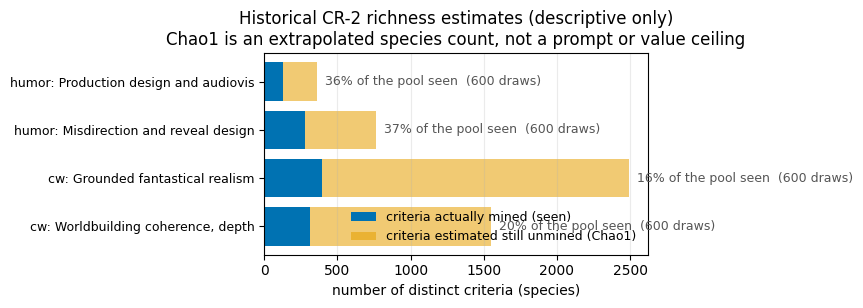

cw     Worldbuilding coherence, depth, an seen= 312 unseen≈   1235  (20% of pool mined in 600 draws)
cw     Grounded fantastical realism       seen= 395 unseen≈   2100  (16% of pool mined in 600 draws)
humor  Misdirection and reveal design     seen= 281 unseen≈    483  (37% of pool mined in 600 draws)
humor  Production design and audiovisual  seen= 128 unseen≈    231  (36% of pool mined in 600 draws)


In [39]:
# The same story as real numbers, for all four pilot metrics: seen vs still-unseen criteria.
import json, numpy as np, matplotlib.pyplot as plt
pilot = json.load(open("data/cr2_realdata_pilot_v1.json"))
rows = pilot["rows"]
names = [f"{r['task']}: {r['name'][:30]}" for r in rows]
seen   = np.array([r["components"]["K_species"] for r in rows])
unseen = np.array([max(0.0, r["components"]["chao_unseen"]) for r in rows])
draws  = [r["components"]["N_stream"] for r in rows]

fig, ax = plt.subplots(figsize=(8.6, 0.7 + 0.62 * len(rows)))
y = np.arange(len(rows))
ax.barh(y, seen, color="#0072B2", label="criteria actually mined (seen)")
ax.barh(y, unseen, left=seen, color="#E69F00", alpha=.55,
        label="criteria estimated still unmined (Chao1)")
for i, r in enumerate(rows):
    frac = seen[i] / (seen[i] + unseen[i])
    ax.text(seen[i] + unseen[i], i, f"  {frac:.0%} of the pool seen  ({draws[i]} draws)",
            va="center", fontsize=9, color="#555")
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("number of distinct criteria (species)")
ax.set_title("Historical CR-2 richness estimates (descriptive only)\n"
             "Chao1 is an extrapolated species count, not a prompt or value ceiling")
ax.legend(loc="lower right", fontsize=9, frameon=False)
ax.grid(axis="x", alpha=.25)
plt.tight_layout(); plt.show()
for r in rows:
    c = r["components"]
    frac = c["K_species"] / (c["K_species"] + max(0.0, c["chao_unseen"]))
    print(f"{r['task']:6s} {r['name'][:34]:34s} seen={c['K_species']:4d} "
          f"unseen≈{c['chao_unseen']:7.0f}  ({frac:.0%} of pool mined in {c['N_stream']} draws)")

> **V12 correction (2026-07-13).** The fixed-target `R_E=I(M;b(p))` and `H(M)` discussion retained below is the legacy auxiliary channel. V12 uses hard executor behavior `b(p)` for novelty, but its primary value is the anchor-free Reconstruction-MCQ probability `V_ann(p)`. For the frozen menu and ordered `T8`, all finite prompts map to 256 hard annotation states, so exhaustive evaluation supplies `U_state=max_s V_ann(s) <= C=1-q_no_demo(target)`. The certified all-finite-prompt interval is `[best evaluated, U_state]`; capture-recapture supplies the complementary proposer-relative behavior/value bounds. CR-3 process/status certificates use only scheduled never-absorbed checkpoints or final confirmation; monitor rows are adaptive and absorbed.

### 8b. CR-3: executor-indexed prompt-articulation ceiling

Fix a metric target `M`, executor/readout `E`, ordered probe panel `X`, initial pool `Omega_N`, and frozen proposer mixture `Q`. For one prompt,

```
R_E(p;M) = I(M ; binarize(E(p,X)))
A_E(M;P) = sup_{p in P} R_E(p;M),  P = Omega_N union support(Q).
```

The target chain is

```
R_E(p;M) <= A_E(M;P) <= I(M;X) <= H(M).
```

CR-3 bootstraps the target and every initial-pool prompt through one immutable, content-addressed executor cache. Fresh proposal attempts use distinct logged seeds and exact family quotas. Monitor batches may choose when to stop; only separately seeded, never-absorbed scheduled checkpoints or final confirmation are bound-grade.

#### The two certified conversions

For the exact best pool prompt `R_Omega`, define each audit draw's gain
`G(p)=max(0,R_E(p;M)-R_Omega)` in `[0,H(M)-R_Omega]`.

1. **Finite mining horizon.** Per-family empirical-Bernstein mean bounds and DKW gain-CDF envelopes receive separate, simultaneous error allocations. For predeclared future counts `m_f`, CR-3 reports the smaller of the mean/sum and integrated expected-maximum bounds. This is an upper bound on the **expected best single prompt after that budget**, not an all-support supremum.
2. **Full proposer support.** Exact binary executor patterns form a genuine partition. If an external assumption says every support pattern has mixture mass at least `p_min`, and the exact missing-mass UCB is below `p_min`, then every support behavior is represented and the pool optimum is the ceiling over `Omega_N union support(Q)`.

Fuzzy novelty remains a mining diagnostic. No substitutability, checklist submodularity, Good-Toulmin value extrapolation, design-effect patch, or fitted asymptote enters either certificate.

> **V12 scope note.** Exact-support promotion is inactive unless an external `--p-min` or `--value-p-min` is supplied. Behavioral support exhaustion promotes a value ceiling only when value is established as a function of exact behavior.


#### How the bound tightens

- **Mine more:** enlarges the pool, can raise `R_Omega`, and should push all-draw gains toward zero.
- **Audit more:** shrinks Clopper-Pearson, empirical-Bernstein, and DKW confidence penalties at the frozen pool. It cannot change the underlying gain distribution.
- **Choose the horizon explicitly:** a bound for 100 future prompts says nothing about 10,000 future prompts.
- **Broaden proposer families:** strengthens prompt-class scope but can reveal new behavior and loosen the bound.
- **Increase or resample probes:** needed for deployment-distribution claims; a fixed-panel certificate does not generalize itself.
- **Defend `p_min` externally:** audit data may test whether `U_exact < p_min`, but it cannot identify a useful `p_min` from the same captures.

This separation makes tightening predictable: mining changes the estimand's residual; confirmation sample size changes only uncertainty.

> **Dated status.** This paragraph records the July 11 state. Current status must be read from the immutable v12 `confirmation/certificate.json`; replace this note when a valid endpoint is available.

#### Current result status: no valid CR-3 endpoint yet

The four `cr3_pilot_v2.json` intervals are withdrawn as certificates because their legacy streams do not establish the v2 iid proposal provenance. The first July 11 live loop is also withdrawn: one shared batch seed produced repeated prompts and some family quotas were silently empty. That job was terminated.

The repaired loop additionally rebases the target and full initial pool on the exact same hashed probe panel, uses deterministic content seeds, persists signatures across worker processes, rejects missing strata, reconstructs pools only from an ordered ledger, and isolates confirmation artifacts. Until a new `confirmation/certificate.json` is produced under that protocol, this notebook intentionally shows no CR-3 numeric ceiling.

#### What we can measure today (DESCRIPTIVE): the discovery curve, replayed from the legacy streams

No certificate is implied here — this is the *measured* shape of mining, using the pre-v2 GLM
streams (verified: 200/200 unique criterion texts per family, so the v1 duplication failure does
not touch them). Under the i.i.d.-within-family premise any within-family order is exchangeable,
so replaying the stream as a growing prefix — rebuild the species map on the prefix, audit the
next unseen window — shows how the novelty level falls as the pool grows, and how fast. The v2
loop (running) will produce the bound-grade version of this curve; dashed projections are a local
power-law fit, descriptive only.


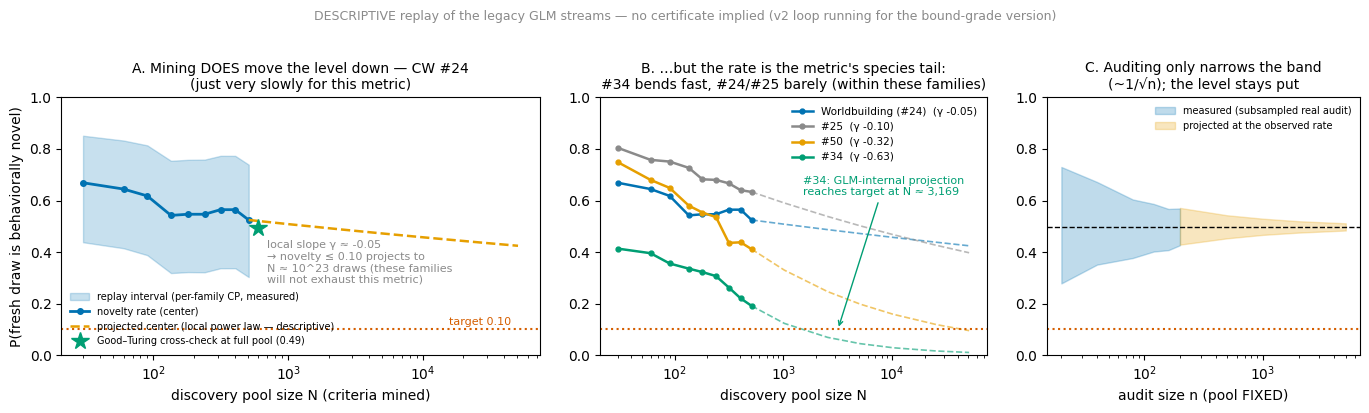

#24: novelty 0.67 @N=90 → 0.52 @N=510 (pool grew 5.7×); Good–Turing at the full 600-pool agrees: 0.49.
     Local slope γ≈-0.05 → halving novelty needs ≈3,500,502× more draws: a very heavy species tail for this metric.
#34: γ≈-0.63 → novelty ≤0.10 projected at N≈3,169 draws (descriptive extrapolation).
All numbers here are DESCRIPTIVE (measured replay + power-law projection); certified
endpoints come only from the v2 loop's confirmation/certificate.json when it completes.


In [40]:
# DESCRIPTIVE replay: mining moves the novelty level down (A, B); auditing only narrows it (C)
import json, numpy as np, matplotlib.pyplot as plt
BLUE, GREEN, ORANGE, RED, GREY = "#0072B2", "#009E73", "#E69F00", "#D55E00", "#8A8A8A"
mc = json.load(open("data/cr3_mining_curve.json"))
d24 = mc["cw:Worldbuilding (#24)"]
shrink = json.load(open("data/cr3_shrink_m24.json"))

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(13.8, 4.0),
                                    gridspec_kw={"width_ratios": [1.3, 1.05, 0.85]})
fig.suptitle("DESCRIPTIVE replay of the legacy GLM streams — no certificate implied "
             "(v2 loop running for the bound-grade version)", fontsize=9, color=GREY, y=1.02)

# --- A: mining axis, CW#24 — measured prefix-replay interval, then projected ------------------
cv = d24["curve"]
Ns = [r["N"] for r in cv]
axA.fill_between(Ns, [r["L0"] for r in cv], [r["U0"] for r in cv], color=BLUE, alpha=.22,
                 label="replay interval (per-family CP, measured)")
axA.plot(Ns, [r["p"] for r in cv], "-o", color=BLUE, lw=2, ms=4, label="novelty rate (center)")
pj = [r for r in d24["projection"] if r["N"] <= 60000]
axA.plot([r["N"] for r in pj], [r["p"] for r in pj], "--", color=ORANGE, lw=1.8,
         label="projected center (local power law — descriptive)")
axA.plot([d24["n_draws_full"]], [d24["good_turing_full_pool"]], "*", color=GREEN, ms=13,
         label=f"Good–Turing cross-check at full pool ({d24['good_turing_full_pool']:.2f})")
axA.axhline(0.10, color=RED, ls=":", lw=1.5)
axA.text(45000, 0.115, "target 0.10", color=RED, fontsize=8, ha="right")
Nt = d24["N_for_U0_le_0.10"]
axA.text(700, 0.28, f"local slope γ ≈ {d24['gamma_local']:.2f}\n→ novelty ≤ 0.10 projects to\n"
         f"N ≈ 10^{int(np.log10(Nt))} draws (these families\nwill not exhaust this metric)",
         fontsize=8, color=GREY)
axA.set_xscale("log"); axA.set_ylim(0, 1)
axA.set_xlabel("discovery pool size N (criteria mined)")
axA.set_ylabel("P(fresh draw is behaviorally novel)")
axA.set_title("A. Mining DOES move the level down — CW #24\n(just very slowly for this metric)",
              fontsize=10)
axA.legend(fontsize=7, frameon=False, loc="lower left")

# --- B: same replay for all 4 pilots — the decline RATE is the metric's species tail ----------
cols = {"cw:Worldbuilding (#24)": BLUE, "cw:#25": GREY, "humor:#50": ORANGE, "humor:#34": GREEN}
for nm, col in cols.items():
    m = mc[nm]
    axB.plot([r["N"] for r in m["curve"]], [r["p"] for r in m["curve"]], "-o", color=col,
             lw=1.8, ms=3.5, label=f"{nm.split(':')[-1]}  (γ {m['gamma_local']:+.2f})")
    pjm = [r for r in m["projection"] if r["N"] <= 60000]
    axB.plot([r["N"] for r in pjm], [r["p"] for r in pjm], "--", color=col, lw=1.2, alpha=.6)
axB.axhline(0.10, color=RED, ls=":", lw=1.5)
n34 = mc["humor:#34"]["N_for_U0_le_0.10"]
axB.annotate(f"#34: GLM-internal projection\nreaches target at N ≈ {n34:,.0f}",
             xy=(n34, 0.1), xytext=(1500, 0.62), fontsize=8, color=GREEN,
             arrowprops=dict(arrowstyle="->", color=GREEN, lw=1))
axB.set_xscale("log"); axB.set_ylim(0, 1)
axB.set_xlabel("discovery pool size N")
axB.set_title("B. …but the rate is the metric's species tail:\n#34 bends fast, #24/#25 barely"
              " (within these families)", fontsize=10)
axB.legend(fontsize=7.5, frameon=False, loc="upper right")

# --- C: audit axis — more auditing only narrows the band at a FIXED pool ----------------------
for row, col, lab in [(shrink["measured_subsample"], BLUE, "measured (subsampled real audit)"),
                      (shrink["projected_at_phat"], ORANGE, "projected at the observed rate")]:
    axC.fill_between([r["n"] for r in row], [r["lo"] for r in row], [r["hi"] for r in row],
                     color=col, alpha=.25, label=lab)
axC.axhline(shrink["p_hat"], color="k", lw=1, ls="--")
axC.axhline(0.10, color=RED, ls=":", lw=1.5)
axC.set_xscale("log"); axC.set_ylim(0, 1)
axC.set_xlabel("audit size n (pool FIXED)")
axC.set_title("C. Auditing only narrows the band\n(~1/√n); the level stays put", fontsize=10)
axC.legend(fontsize=7, frameon=False)

plt.tight_layout(); plt.show()

g24, g34 = mc["cw:Worldbuilding (#24)"], mc["humor:#34"]
print(f"#24: novelty {g24['curve'][0]['p']:.2f} @N=90 → {g24['curve'][-1]['p']:.2f} @N=510 "
      f"(pool grew 5.7×); Good–Turing at the full 600-pool agrees: {g24['good_turing_full_pool']:.2f}.")
print(f"     Local slope γ≈{g24['gamma_local']:.2f} → halving novelty needs ≈"
      f"{2**(1/abs(g24['gamma_local'])):,.0f}× more draws: a very heavy species tail for this metric.")
print(f"#34: γ≈{g34['gamma_local']:.2f} → novelty ≤0.10 projected at N≈{g34['N_for_U0_le_0.10']:,.0f} "
      "draws (descriptive extrapolation).")
print("All numbers here are DESCRIPTIVE (measured replay + power-law projection); certified")
print("endpoints come only from the v2 loop's confirmation/certificate.json when it completes.")


#### Two target-indexed ladders, not one mixed ladder

For a frozen operational target `M_b`:

```
best achieved prompt <= A_E(M_b;P) <= I(M_b;X) <= H(M_b).
```

For the prompt-independent ideal `M*`, only after it is separately identified:

```
best achieved prompt <= A_E(M*;P) <= I(M*;X) <= H(M*).
```

There is no automatic inequality between the two ladders. An operationalization can omit ideal distinctions and add executor-specific artifacts. Therefore `H(M_b)` and `I(M_b;X)` are neither floors nor ceilings for `M*`; CR-3 capture over prompts cannot identify `M*`.

#### Reporting rule

A paper-grade CR-3 result must name, in one sentence, the target construction, executor revision and readout, ordered probe panel or deployment confidence layer, initial pool, proposer families and weights, validity predicate, future horizon, alpha allocation, and any external `p_min`.

Report the exact pool optimum and the confirmation certificate together. Report monitor trajectories, fuzzy novelty, Chao/Good-Turing, Hill, and power-law projections only as descriptive context. Never turn a zero-novelty audit into a support ceiling without the exact partition and positivity premise.

> **V12 reporting.** V12 reports a predeclared 95% primary tier and a 90% sensitivity tier on the same audit rows. The all-finite cap is exact and untiered; `mcq_identity_final.json` is achieved task-level identity, not an upper bound.


#### CR-3 v12: every test applied to one metric

The figure below follows the actual run order and separates three evidence roles: frozen
prerequisites, adaptive monitor rows that are absorbed, and never-absorbed audits that can support
certificates. The three result lanes are reported separately because behavioral saturation,
finite-horizon value plateau, and the fixed-instrument all-prompt cap answer different questions.


In [1]:
from IPython.display import HTML, display

display(HTML(r'''
<style>
#cr3v12 {
  --blue:#2474a6; --teal:#16856b; --amber:#b56b00; --red:#b43b32;
  --violet:#6b5ca5; --line:rgba(110,120,130,.42);
  max-width:1180px; margin:18px auto; color:inherit;
  font-family:system-ui,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;
}
#cr3v12 * { box-sizing:border-box; }
#cr3v12 h3 { margin:0 0 6px; font-size:20px; letter-spacing:0; }
#cr3v12 .sub { margin:0 0 13px; opacity:.78; font-size:13px; line-height:1.45; }
#cr3v12 .legend { display:flex; flex-wrap:wrap; gap:14px; margin-bottom:13px; font-size:12px; }
#cr3v12 .key { display:inline-flex; align-items:center; gap:6px; }
#cr3v12 .sw { width:11px; height:11px; border-radius:2px; }
#cr3v12 .steps { display:grid; grid-template-columns:repeat(3,minmax(0,1fr)); gap:10px; }
#cr3v12 .step {
  min-height:172px; padding:12px 13px; border:1px solid var(--line);
  border-left:5px solid var(--accent); border-radius:6px;
}
#cr3v12 .scope { font-size:10px; font-weight:750; color:var(--accent); text-transform:uppercase; }
#cr3v12 .step h4 { margin:4px 0 7px; font-size:14px; letter-spacing:0; }
#cr3v12 .step p { margin:0; font-size:12px; line-height:1.45; }
#cr3v12 .checks { margin:7px 0 0; padding-left:17px; font-size:11px; line-height:1.42; }
#cr3v12 .role { margin-top:8px !important; padding-top:7px; border-top:1px solid var(--line); font-weight:650; }
#cr3v12 .phase { margin-top:7px; padding:7px 8px; border-left:4px solid var(--phase); background:rgba(127,127,127,.05); }
#cr3v12 .phase b { display:block; margin-bottom:3px; font-size:11px; }
#cr3v12 .lanes { display:grid; grid-template-columns:repeat(3,minmax(0,1fr)); gap:10px; margin-top:12px; }
#cr3v12 .lane { padding:11px 13px; border-top:4px solid var(--accent); background:rgba(127,127,127,.06); }
#cr3v12 .lane h4 { margin:0 0 5px; font-size:13px; letter-spacing:0; }
#cr3v12 .lane p { margin:0; font-size:12px; line-height:1.45; }
#cr3v12 .report {
  margin-top:10px; padding:10px 13px; border-left:5px solid var(--violet);
  background:rgba(107,92,165,.08); font-size:12px; line-height:1.5;
}
#cr3v12 code { font-size:11px; }
@media (max-width:880px) {
  #cr3v12 .steps, #cr3v12 .lanes { grid-template-columns:1fr; }
  #cr3v12 .step { min-height:0; }
}
</style>

<div id="cr3v12">
  <h3>CR-3 v12: tests applied to each metric, in execution order</h3>
  <p class="sub">The primary value unit is anchor-free Reconstruction-MCQ probability.
  Hard executor behavior is a separate discovery channel. Historical prompts may raise the
  achieved pool, but only predeclared never-absorbed audits support certificates.</p>

  <div class="legend">
    <span class="key"><span class="sw" style="background:var(--blue)"></span>frozen prerequisite</span>
    <span class="key"><span class="sw" style="background:var(--amber)"></span>adaptive and absorbed</span>
    <span class="key"><span class="sw" style="background:var(--teal)"></span>never absorbed / bound-grade</span>
    <span class="key"><span class="sw" style="background:var(--red)"></span>headline demotion, formal result retained</span>
  </div>

  <div class="steps">
    <div class="step" style="--accent:var(--blue)">
      <div class="scope">1 &middot; Run level</div>
      <h4>Freeze and validate the contract</h4>
      <p>Write one immutable manifest before scoring.</p>
      <ul class="checks">
        <li>checkpoint, hierarchy, code, executor/proposer/reconstructor revisions, readouts, and runtime versions</li>
        <li>one task and one R-level per complete codebook; substantive name/index match</li>
        <li>family modes, exact quotas, thresholds, horizon, checkpoint slots, and alpha fixed</li>
        <li>resume or evidence namespace mismatch fails closed</li>
      </ul>
      <p class="role">No statistical claim exists if this stage fails.</p>
    </div>

    <div class="step" style="--accent:var(--blue)">
      <div class="scope">2 &middot; Metric + task bank</div>
      <h4>Bootstrap on one executor/probe namespace</h4>
      <p>Re-score the source-checkpoint prompt pool and target forms on the same ordered 300 probes.
      Score one frozen target behavior (orbit mean where configured) for every task-level codebook candidate.</p>
      <ul class="checks">
        <li>finite shapes, exact probe hash, executor revision, and processed-logit protocol</li>
        <li>duplicate prompt text resolves to one content-addressed signature</li>
        <li>legacy alignment is diagnostic only</li>
        <li>historical candidates are not imported until after the MCQ instrument is frozen</li>
      </ul>
      <p class="role">Builds the achieved pool; it is not a fresh audit.</p>
    </div>

    <div class="step" style="--accent:var(--blue)">
      <div class="scope">3 &middot; Task level, before search</div>
      <h4>Design and freeze the finite MCQ instrument</h4>
      <p>Use bootstrap behavior only to form hard, non-clone, disagreeing menus. Score blind,
      position-counterbalanced no-demo queries, and prospectively evaluate each admissible menu with
      its ordered eight-item teaching panel <code>T8</code>.</p>
      <ul class="checks">
        <li>enough same-task, same-level distractors with frozen 120-item design-subset disagreement</li>
        <li>maximum option prior &le; 0.35</li>
        <li>target prior within &plusmn;0.10 of 1/4 and normalized entropy &ge; 0.90</li>
        <li>enumerate all 256 hard YES/NO states on each frozen <code>T8</code></li>
        <li>state-live requires a unique target winner and positive lift for at least one state</li>
        <li>choose the live prior-passing design with largest <code>U_state</code>; otherwise freeze a formal-only fallback</li>
      </ul>
      <p class="role">Hard design failure aborts; prior imbalance demotes value headlines.</p>
    </div>

    <div class="step" style="--accent:var(--blue)">
      <div class="scope">4 &middot; Per metric</div>
      <h4>Attach behavior and look up value</h4>
      <p>After instrument freeze, hash-check and re-score historical candidate-only prompts. Threshold
      each prompt's exact executor probabilities on <code>T8</code> into one eight-bit state, then retrieve
      its precomputed annotation, shuffled, and no-demo values from the exhaustive table.</p>
      <ul class="checks">
        <li><code>V_ann=max(0,q_ann-max(q0,q_shuffle))</code>; each <code>q</code> is the exact block mean</li>
        <li><code>q0</code> is the normalized target processed-logit mean, not a sampled Bernoulli rate</li>
        <li>no prompt rows filtered after value is observed; the same state always has the same value</li>
        <li>full posterior matrices, transcript hashes, and provisional/final semantic SHA must match</li>
        <li>headline eligibility requires prior balance, <code>C &ge; 0.10</code>, and <code>U_state &ge; 0.02</code></li>
        <li>behavioral kappa is retained as a near-clone diagnostic, not a value gate</li>
      </ul>
      <p class="role"><code>U_state=max_s V_ann(s)</code> is the exact fixed-instrument all-finite-prompt envelope; <code>C=1-q0(target)</code> is a coarser check.</p>
    </div>

    <div class="step" style="--accent:var(--violet)">
      <div class="scope">5 &middot; Per-metric loop, two evidence roles</div>
      <h4>Checkpoint first; then monitor and absorb</h4>
      <div class="phase" style="--phase:var(--teal)"><b>5A &middot; Bound-grade checkpoint</b>
      At a scheduled iteration, draw a separately seeded, never-absorbed audit against the current pool.</div>
      <div class="phase" style="--phase:var(--amber)"><b>5B &middot; Adaptive monitor</b>
      Propose, score, and value the monitor batch; use it for stopping, ledger it, and absorb it.</div>
      <ul class="checks">
        <li>unique seed per proposal attempt; exact quota in all four frozen families</li>
        <li>model revision/config, mode/validator, signature namespace, finite behavior, and MCQ hashes</li>
        <li>target, patience, max-iteration, and minimum-change rules use monitor rows only</li>
        <li>append-only ledger is replayed field by field on resume</li>
      </ul>
      <p class="role">Checkpoint is bound-grade. Monitor is adaptive and never reported as a certificate.</p>
    </div>

    <div class="step" style="--accent:var(--teal)">
      <div class="scope">6 &middot; Per metric, after stopping</div>
      <h4>Never-absorbed final confirmation</h4>
      <p>Draw 100 new prompts per family with a disjoint seed namespace. Behavior-score and
      MCQ-value them against the frozen final pool; never add them to that pool.</p>
      <ul class="checks">
        <li>same exact quotas, readout IDs, probes, codebook, and value channel</li>
        <li>confirmation paths are excluded from every pool loader</li>
        <li>same immutable rows recomputed at primary 95% and sensitivity 90%</li>
        <li>90%-only directions receive a SUGGESTIVE label</li>
      </ul>
      <p class="role">This is the bound-grade endpoint.</p>
    </div>
  </div>

  <div class="lanes">
    <div class="lane" style="--accent:var(--teal)">
      <h4>Behavioral discovery status</h4>
      <p>Clopper-Pearson interval for <code>tau</code>-novel mass under frozen proposer mixture
      <code>Q</code>: UCB &le; target means <b>SATURATED</b>; LCB &gt; target means
      <b>UNSATURATED</b>; otherwise <b>UNRESOLVED</b>. This is not all-prompt support saturation.</p>
    </div>
    <div class="lane" style="--accent:var(--amber)">
      <h4>Prompt-value status</h4>
      <p>Empirical-Bernstein plus DKW bounds on expected best gain over the declared future
      <code>Q</code> horizon: UCB &le; epsilon means <b>PLATEAUED</b>; LCB &gt; epsilon means
      <b>RISING</b>; otherwise <b>UNRESOLVED</b>.</p>
    </div>
    <div class="lane" style="--accent:var(--red)">
      <h4>All-finite-prompt interval</h4>
      <p>For the frozen MCQ instrument: <code>[best evaluated through this audit, U_state]</code>,
      where <code>U_state</code> is the exhaustive maximum over 256 hard <code>T8</code> states and
      <code>U_state &le; C=1-q0(target)</code>. This cap is audit-independent and is not a capture-recapture claim.</p>
    </div>
  </div>

  <div class="report">
    <b>Prospective bank allocation.</b> Corrected production runs set <code>study-alpha=0.05</code>.
    With <code>n</code> metrics and <code>L</code> bound-grade slots per metric, each primary cell receives
    <code>0.05/(nL)</code>; the separately labelled 90% sensitivity tier receives <code>0.10/(nL)</code>.
    Current runs leave
    <code>p_min</code> and <code>value_p_min</code> unset, so exact-support promotion is inactive. The task-level
    <code>mcq_identity_final.json</code> is achieved bank identity, not an upper bound.
  </div>
</div>
'''))


---
## 9. What a *reconstructed* prompt actually looks like — a DIAGNOSTIC gallery

> **RETRACTED (2026-07-12 retro audit):** the id-accuracy numbers below are PRIOR artifacts. A blind no-demonstration control on the exact regenerated menus (all 24 verified dS=0) shows the reconstructor picks the target from the MENU ALONE at 0.65 (hard) / 0.69 (random) — above the with-demonstrations 0.50 / 0.63. Corrected demonstration lift is ≈ 0 or negative: on peer-review × Llama-8B the MCQ channel carried no net behavioral information (menu centralness leaks the answer; noisy 8B verdicts actively mislead). Do not quote these numbers as behavioral identification. Audit: `notebooks/data/no_demo_audit_v1.json`.
>
> **Read this first:** the cards below are NOT how we score reconstruction. The **reported
> recovery metric is MCQ** (`run_r2_recovery.py`, default `--mode mcq --distractor hard`): the
> reconstructor must *pick* the true metric out of behaviorally-hard alternatives, which is
> bounded, prior-robust, and has a clean 1/k chance baseline. The measured 3-arm comparison
> (peer-review, 12 metrics): identification accuracy **0.50 (hard) / 0.63 (random = the easy
> baseline, inflated as expected)**, and free-generation recovery **0.016 bits vs MCQ-hard's
> 0.117** on the discriminating metrics — free is the weakest channel. This gallery uses the
> free channel for ONE reason: its guesses are *readable*, which makes failure modes visible.

Everywhere above, “recovery” meant: hand a reconstructor a metric's high- and low-scoring texts (never the metric's name or definition), let it *guess* a scoring rubric from behavior alone, then measure how well that guessed rubric `m̂` reproduces the metric's verdicts on held-out texts. This section shows the guesses themselves, next to what the metric actually says, for a spread of metrics across four tasks.

**How to read each card.** `R_recon` is how many bits the *reconstructed* prompt recovers; `R_desc` is how many the metric's *true description* recovers, scored identically. Three things can happen, and all three are here:

- **the guess beats the description** (`R_recon > R_desc`) — behavior alone found a sharper prompt than the human wording;
- **the guess matches it** — the metric's content is out in the open;
- **the guess collapses to a generic “quality” prior** (`R_recon` near 0 or *negative*) — seeing only which texts scored high vs low, the model couldn't tell *what* was being rewarded, so it fell back on a catch-all notion of quality (“the text looks polished,” “a reviewer said something nice”). That catch-all barely tracks the actual metric — and when it tracks it *backwards* (polished ≠ what this metric measures), recovery goes **negative**: the guess is worse than a coin flip. This is the exact failure the reconstructor prompt was later hardened against.

Source: `outputs/metric_seam_pilot/reconstruction/` (157 metrics, 4 tasks; the `judge` channel is the reconstruction, `judge_truedesc` is the true description scored the same way).

> The retraction applies to these historical menus. V12 prospectively tests blind menu priors before prompt search and marks prior-, cap-, or kappa-ineligible panels formal-only; it does not rehabilitate the gallery's numbers.


In [42]:
import json, math
from IPython.display import HTML, display

_rows = [json.loads(l) for l in open("data/prompt_optimality_20260703/recon_results.jsonl")]
from collections import defaultdict
_by = defaultdict(dict)
for r in _rows:
    _by[(r["task"], r["name"])][r["channel"]] = r
def _ok(x): return isinstance(x, (int, float)) and not math.isnan(x)
_pairs = [(k, v) for k, v in _by.items() if "judge" in v and "judge_truedesc" in v
          and _ok(v["judge"].get("R")) and _ok(v["judge_truedesc"].get("R"))]

def _pick(pred, key, n=1):
    return sorted([p for p in _pairs if pred(p)], key=key)[:n]

beats = _pick(lambda p: p[1]["judge"]["R"] - p[1]["judge_truedesc"]["R"] > 0.05,
              lambda p: -p[1]["judge"]["R"], 2)
match = _pick(lambda p: abs(p[1]["judge"]["R"] - p[1]["judge_truedesc"]["R"]) <= 0.06
              and p[1]["judge"]["R"] > 0.45, lambda p: -p[1]["judge"]["R"], 2)
fail  = _pick(lambda p: p[1]["judge_truedesc"]["R"] - p[1]["judge"]["R"] > 0.25,
              lambda p: p[1]["judge"]["R"], 2)

_BAND = {"beats": ("#009E73", "the guess beat the human description"),
         "match": ("#0072B2", "the guess matched the description"),
         "fail":  ("#D55E00", "the guess collapsed to a generic quality prior")}

def card(p, band):
    (task, name), v = p
    j, td = v["judge"], v["judge_truedesc"]
    col, blurb = _BAND[band]
    mhat = j["m_hat"].strip().replace("\n", "<br>")
    tdesc = td["m_hat"].strip().replace("\n", " ")
    return f"""
<div style="border:1px solid rgba(128,128,128,.35);border-left:4px solid {col};border-radius:8px;
     margin:12px 0;font-family:-apple-system,sans-serif;max-width:860px;overflow:hidden">
 <div style="padding:8px 12px;background:rgba(128,128,128,.08);
      border-bottom:1px solid rgba(128,128,128,.2)">
   <span style="font-size:10.5px;font-weight:700;color:{col};text-transform:uppercase">{blurb}</span>
   <span style="font-size:10.5px;opacity:.6;margin-left:8px">[{task}]</span>
   <div style="font-weight:600;font-size:13.5px;margin-top:2px">{name}</div>
   <div style="font-size:12px;margin-top:3px">
     <b style="color:{col}">reconstructed prompt recovers R = {j['R']:+.2f} bits</b>
     &nbsp;&middot;&nbsp; true description recovers R = {td['R']:+.2f} bits</div>
 </div>
 <div style="padding:9px 13px">
   <div style="font-size:10.5px;font-weight:700;opacity:.6;margin-bottom:3px">
     WHAT THE RECONSTRUCTOR GUESSED (from behavior alone):</div>
   <div style="font-size:12.5px;line-height:1.5;font-style:italic;opacity:.92">&ldquo;{mhat}&rdquo;</div>
   <div style="font-size:10.5px;font-weight:700;opacity:.6;margin:9px 0 3px">
     WHAT THE METRIC ACTUALLY SAYS:</div>
   <div style="font-size:12px;line-height:1.45;opacity:.8">&ldquo;{tdesc}&rdquo;</div>
 </div>
</div>"""

html = ""
for band, ps in [("beats", beats), ("match", match), ("fail", fail)]:
    html += "".join(card(p, band) for p in ps)
display(HTML(html))
print(f"gallery drawn from {len(_pairs)} reconstructed/true-description pairs "
      f"({sum(1 for p in _pairs if p[1]['judge']['R'] - p[1]['judge_truedesc']['R'] > 0.05)} beat the "
      f"description, {sum(1 for p in _pairs if p[1]['judge_truedesc']['R'] - p[1]['judge']['R'] > 0.25)} "
      f"collapsed to a generic prior)")

gallery drawn from 111 reconstructed/true-description pairs (10 beat the description, 53 collapsed to a generic prior)
